# Brain Tumor Classification using Custom CNN with Explainable AI (XAI)

## Dataset Description
- **Source:** Mendeley Data — *Brain Cancer MRI Dataset* ([DOI: 10.17632/mk56jw9rns](https://data.mendeley.com/datasets/mk56jw9rns))
- **Modality:** T1-weighted MRI scans (Brain)
- **Classes (3):**

| Class | Folder Name | Description |
|-------|------------|-------------|
| Glioma | `brain_glioma` | Glioma tumor MRI scans |
| Meningioma | `brain_menin` | Meningioma tumor MRI scans |
| Pituitary | `brain_tumor` | Pituitary tumor MRI scans |

- **Image Size:** Resized to 224×224×3 (RGB)
- **Data Split:** 85% Train / 15% Test (stratified, `random_state=42`)
- **Validation:** 5-Fold Stratified Cross-Validation on the training set

## Methodology
1. Images loaded via OpenCV (BGR) and resized to 224×224
2. Custom CNN architecture with Conv2D, BatchNormalization, Dropout, L2 regularization
3. 5-Fold Stratified Cross-Validation with ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
4. Evaluation: Confusion Matrix, Classification Report, ROC-AUC
5. Explainability: Grad-CAM and Grad-CAM++ visualizations

In [1]:
 from google.colab import drive
 drive.mount('/content/drive')
print("Offline mode: Google Drive mount skipped.")

Mounted at /content/drive
Offline mode: Google Drive mount skipped.


In [2]:
#cell 1 to check torch and cuda version
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")
print("CUDA version (compiled):", torch.version.cuda)



Torch version: 2.9.0+cu128
CUDA available: True
GPU name: Tesla T4
CUDA version (compiled): 12.8


In [3]:
# Suppress warnings and set reproducibility seeds
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"✅ All random seeds set to {SEED} for reproducibility.")

✅ All random seeds set to 42 for reproducibility.


In [4]:
# cell 3 to install gdown
# !pip install --upgrade --no-cache-dir gdown
print("Offline mode: gdown install skipped.")

Offline mode: gdown install skipped.


In [5]:
import os

# Download the dataset using wget
# The -O flag saves the file with the specified name
!wget -O brain_tumor_dataset.zip https://data.mendeley.com/public-files/datasets/mk56jw9rns/files/8b95c5c3-d569-42ee-9b52-6019f48a2161/file_downloaded

# Verify the download by listing files in the current directory
!ls -lh brain_tumor_dataset.zip

--2026-02-16 05:29:34--  https://data.mendeley.com/public-files/datasets/mk56jw9rns/files/8b95c5c3-d569-42ee-9b52-6019f48a2161/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/7248a73a-ef7c-4a3c-b98a-b99a98f870f4 [following]
--2026-02-16 05:29:34--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/7248a73a-ef7c-4a3c-b98a-b99a98f870f4
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.218.61.160, 52.92.35.130, 3.5.74.35, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.218.61.160|:443.

In [6]:
# cell 5 to unzip the file (OFFLINE MODE)
import zipfile
import os

# User provided path
zip_path = r"/content/brain_tumor_dataset.zip"
extract_path = os.getcwd() # Extract to current working directory

if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Outer zip extracted.")

        # Check for the nested zip
        nested_zip_path = os.path.join(extract_path, "Brain Cancer -  MRI dataset", "Brain_Cancer raw MRI data.zip")
        if os.path.exists(nested_zip_path):
             print(f"Extracting nested zip {nested_zip_path}...")
             with zipfile.ZipFile(nested_zip_path, 'r') as zip_ref:
                zip_ref.extractall(extract_path) # Extract to root
             print("Nested zip extracted.")

             # The extracted folder might not be "Brain_Image". Let's check rename if necessary.
             # Based on common dataset structures, it might be "Brain_Cancer" or similar.
             # We will check this in the next steps or users might need to adjust.
             # But for now, we ensure extraction.
        else:
            print("Nested zip not found. Checking if content matches expectations.")

    except Exception as e:
        print(f"An error occurred during extraction: {e}")
else:
    print(f"Error: Dataset not found at {zip_path}")

Extracting /content/brain_tumor_dataset.zip...
Outer zip extracted.
Nested zip not found. Checking if content matches expectations.


In [7]:
# cell 6 to import libraries
!pip install split-folders
import splitfolders
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from keras.layers import Input

In [8]:
# cell 7 - Setup paths, detect dataset, and define classes
from pathlib import Path

# Auto-detect project root
PROJECT_ROOT = Path.cwd()
BRAIN_IMAGE_DIR = PROJECT_ROOT / "Brain_Image"  # Default fallback

# Check for the extracted dataset folder
possible_paths = [
    PROJECT_ROOT / "Brain_Cancer",
    PROJECT_ROOT / "Brain Cancer - MRI dataset",
    PROJECT_ROOT / "Brain_Image"
]

found = False
for p in possible_paths:
    if p.exists():
        BRAIN_IMAGE_DIR = p
        found = True
        print(f"✅ Found dataset at: {BRAIN_IMAGE_DIR}")
        break

if not found:
    print(f"⚠️ Dataset folder not found! Searched in: {possible_paths}")
    print(f"Current directory: {PROJECT_ROOT}")

# Split dataset into train/val/test folders (for augmentation preview only)
OUTPUT_DIR = PROJECT_ROOT / "split_dataset"

if not OUTPUT_DIR.exists():
    print("Splitting dataset into train/val/test...")
    splitfolders.ratio(BRAIN_IMAGE_DIR, output=OUTPUT_DIR, seed=42, ratio=(.7, .15, .15), group_prefix=None)
    print("Dataset split completed!")
else:
    print("Split dataset already exists.")

TRAIN_DIR = OUTPUT_DIR / "train"
VAL_DIR = OUTPUT_DIR / "val"
TEST_DIR = OUTPUT_DIR / "test"

# Define classes (3-class brain tumor classification)
classes = {'glioma': 0, 'meningioma': 1, 'pituitary': 2}
class_folder_map = {
    'glioma': 'brain_glioma',
    'meningioma': 'brain_menin',
    'pituitary': 'brain_tumor'
}

print(f"✅ Classes defined: {classes}")
print(f"✅ Directory Map: {class_folder_map}")

✅ Found dataset at: /content/Brain_Cancer
Splitting dataset into train/val/test...


Copying files: 6056 files [00:01, 3430.95 files/s]

Dataset split completed!
✅ Classes defined: {'glioma': 0, 'meningioma': 1, 'pituitary': 2}
✅ Directory Map: {'glioma': 'brain_glioma', 'meningioma': 'brain_menin', 'pituitary': 'brain_tumor'}


In [9]:
# cell 8 to load images using relative paths
import cv2
import os

X = []
Y = []

print("Loading images...")

# Iterate over our defined classes and mapped folders
for cls_name, cls_idx in classes.items():
    folder_name = class_folder_map.get(cls_name)
    if not folder_name:
        print(f"Skipping {cls_name} (no folder map)")
        continue

    cls_path = BRAIN_IMAGE_DIR / folder_name

    if not cls_path.exists():
         print(f"⚠️ Warning: Folder {cls_path} not found!")
         continue

    print(f"Processing {cls_name} from {folder_name}...")

    count = 0
    for file_name in os.listdir(cls_path):
        if not (file_name.lower().endswith('.jpg') or file_name.lower().endswith('.png') or file_name.lower().endswith('.jpeg')):
            continue

        img_path = cls_path / file_name
        try:
            img = cv2.imread(str(img_path), 1)  # 1 for color images
            if img is None:
                continue
            img = cv2.resize(img, (224, 224))
            X.append(img)
            Y.append(cls_idx)
            count += 1
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    print(f"Loaded {count} images for class {cls_name}")

print(f"✅ Loaded {len(X)} images total")


Loading images...
Processing glioma from brain_glioma...
Loaded 2004 images for class glioma
Processing meningioma from brain_menin...
Loaded 2004 images for class meningioma
Processing pituitary from brain_tumor...
Loaded 2048 images for class pituitary
✅ Loaded 6056 images total


In [10]:
# cell 9 - Import preprocessing utilities (used for augmentation preview only)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input

In [11]:
# cell 10 - Augmentation preview generator (NOT used for model training)
# Note: Model training uses raw numpy arrays (xtrain/xtest) via 5-Fold CV.
# This generator is only used to visualize augmentation samples.
def preprocessingImages1(path):
  """Creates an augmented image generator for visualization purposes only."""
  image_data = ImageDataGenerator(
      rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
      zoom_range=0.2, shear_range=0.1, horizontal_flip=True,
      fill_mode='nearest', preprocessing_function=preprocess_input
  )
  image = image_data.flow_from_directory(
      directory=path, target_size=(224, 224), batch_size=32, class_mode='categorical'
  )
  return image

In [12]:
# cell 12 - Create augmentation preview generator (for visualization only)
train_data = preprocessingImages1(str(TRAIN_DIR))

Found 4237 images belonging to 3 classes.


In [13]:
#cell 14 to convert lists to numpy arrays and normalize
X = np.array(X)
Y = np.array(Y)


In [14]:
# cell 14.5 - Data Splitting (Injected to fix missing variables)
from sklearn.model_selection import train_test_split

print("Splitting data into Train and Test sets (85/15)...")
# Using 85/15 split to match the folder structure intent, stratify=Y ensures class balance
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.15, random_state=42, stratify=Y)

print(f"X_train shape: {xtrain.shape}")
print(f"y_train shape: {ytrain.shape}")
print(f"X_test shape: {xtest.shape}")
print(f"y_test shape: {ytest.shape}")

Splitting data into Train and Test sets (85/15)...
X_train shape: (5147, 224, 224, 3)
y_train shape: (5147,)
X_test shape: (909, 224, 224, 3)
y_test shape: (909,)


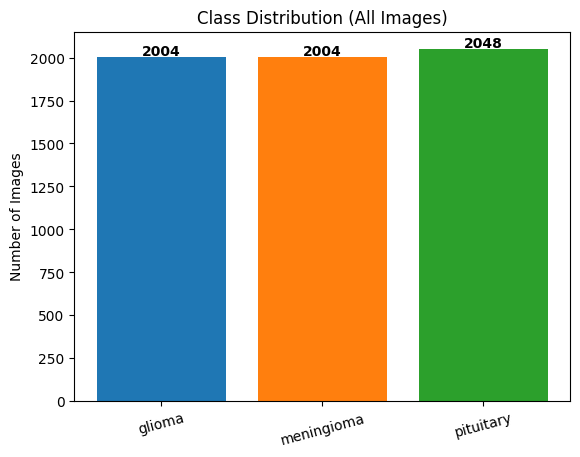


Total images: 6056
  glioma: 2004 (33.1%)
  meningioma: 2004 (33.1%)
  pituitary: 2048 (33.8%)


In [15]:
# cell 15 - Visualize class distribution
import numpy as np, matplotlib.pyplot as plt
from collections import Counter

inv_classes = {v: k for k, v in classes.items()}
counts = Counter(Y)
names = [inv_classes[i] for i in sorted(counts.keys())]
vals  = [counts[i] for i in sorted(counts.keys())]

plt.bar(names, vals, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Class Distribution (All Images)")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
for i, v in enumerate(vals):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.show()

print(f"\nTotal images: {len(Y)}")
for name, count in zip(names, vals):
    print(f"  {name}: {count} ({count/len(Y)*100:.1f}%)")

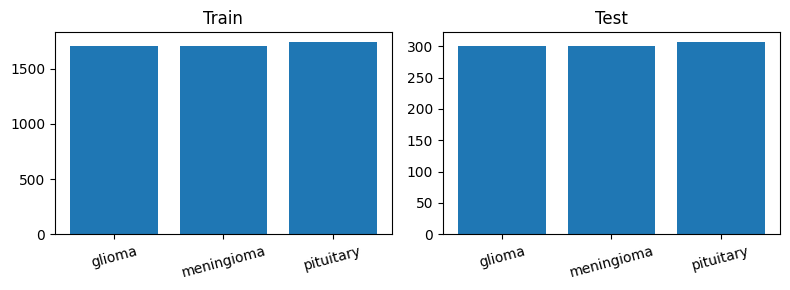

In [16]:
#cell 16 to split the data into train and test sets
# B) OPTIONAL train/test split distribution (run ONLY after creating xtrain, xtest, ytrain, ytest)
try:
    ytrain, ytest  # just to check
    import matplotlib.pyplot as plt
    def bar_dist(y, title):
        c = Counter(y)
        ordered_ids = sorted(c.keys())
        plt.bar([inv_classes[i] for i in ordered_ids],
                [c[i] for i in ordered_ids])
        plt.title(title); plt.xticks(rotation=15)
    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1); bar_dist(ytrain, "Train")
    plt.subplot(1,2,2); bar_dist(ytest, "Test")
    plt.tight_layout(); plt.show()
except NameError:
    print("Run train_test_split first to create ytrain / ytest.")

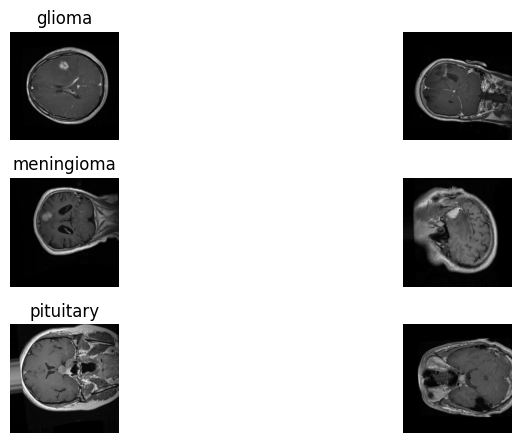

In [17]:
# cell 17 to visualize some samples from the dataset
# C) Show 2 random samples per class
import random, matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
for ci in sorted(inv_classes.keys()):
    idxs = np.where(Y==ci)[0]
    for k in range(2):
        idx = random.choice(idxs)
        plt_idx = ci*2 + k + 1
        plt.subplot(4,2,plt_idx)
        plt.imshow(X[idx][:,:,::-1])  # BGR->RGB
        plt.axis('off')
        if k==0: plt.title(inv_classes[ci])
plt.tight_layout(); plt.show()

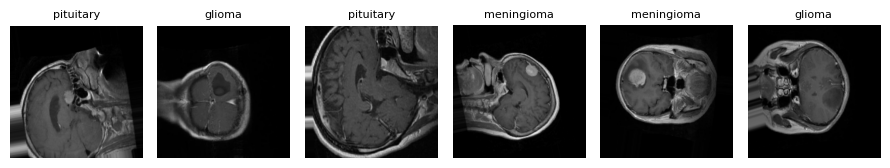

In [18]:
# cell 18 to visualize some samples from the dataset
# D) Quick augmentation preview (needs train_data generator already made)
batch_imgs, batch_labels = next(train_data)
# Invert mobilenet preprocess: x = (x/127.5)-1  => original ≈ (x+1)*127.5
show_imgs = ((batch_imgs + 1)*127.5).clip(0,255).astype('uint8')
plt.figure(figsize=(9,3))
for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(show_imgs[i])
    plt.axis('off')
    plt.title(inv_classes[np.argmax(batch_labels[i])], fontsize=8)
plt.tight_layout(); plt.show()

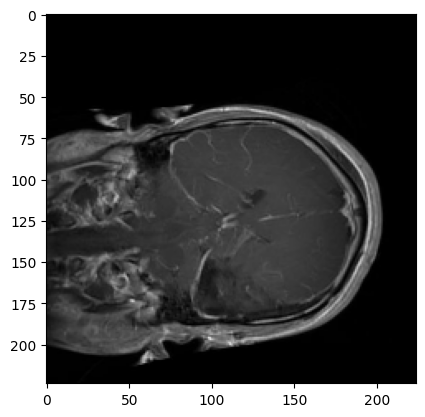

In [19]:
#cell 19 to visualize one image from the dataset
plt.imshow(X[0], cmap='gray')

In [20]:
#cell 20 to check the shape of one image
X[0].shape

(224, 224, 3)

In [21]:
# cell 22 to check the shape of train and test sets
xtrain.shape, xtest.shape

((5147, 224, 224, 3), (909, 224, 224, 3))

In [22]:
# cell 23 - Import model building libraries
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPooling2D, Flatten,
    BatchNormalization, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

In [23]:
# cell 24 to build the model
model = Sequential()


model.add(Conv2D(32, 5, activation='relu',input_shape = (224,224,3))) #3 Conv1D
model.add(MaxPooling2D(pool_size=4)) #2
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Conv2D(64, 5, activation='relu'))
model.add(Conv2D(64, 5, activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Conv2D(128, 5, activation='relu')) #2
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Conv2D(256, 5, activation='relu')) #2
model.add(MaxPooling2D(pool_size=2))
model.add(BatchNormalization())
model.add(Dropout(0.3))


model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001))) #128
model.add(BatchNormalization())
model.add(Dropout(0.5)) #0.5
model.add(Dense(3, activation='softmax'))  # ✅ FIXED: 3 classes (Glioma, Meningioma, Pituitary)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,446,659 (5.52 MB)

 Trainable params: 1,445,187 (5.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

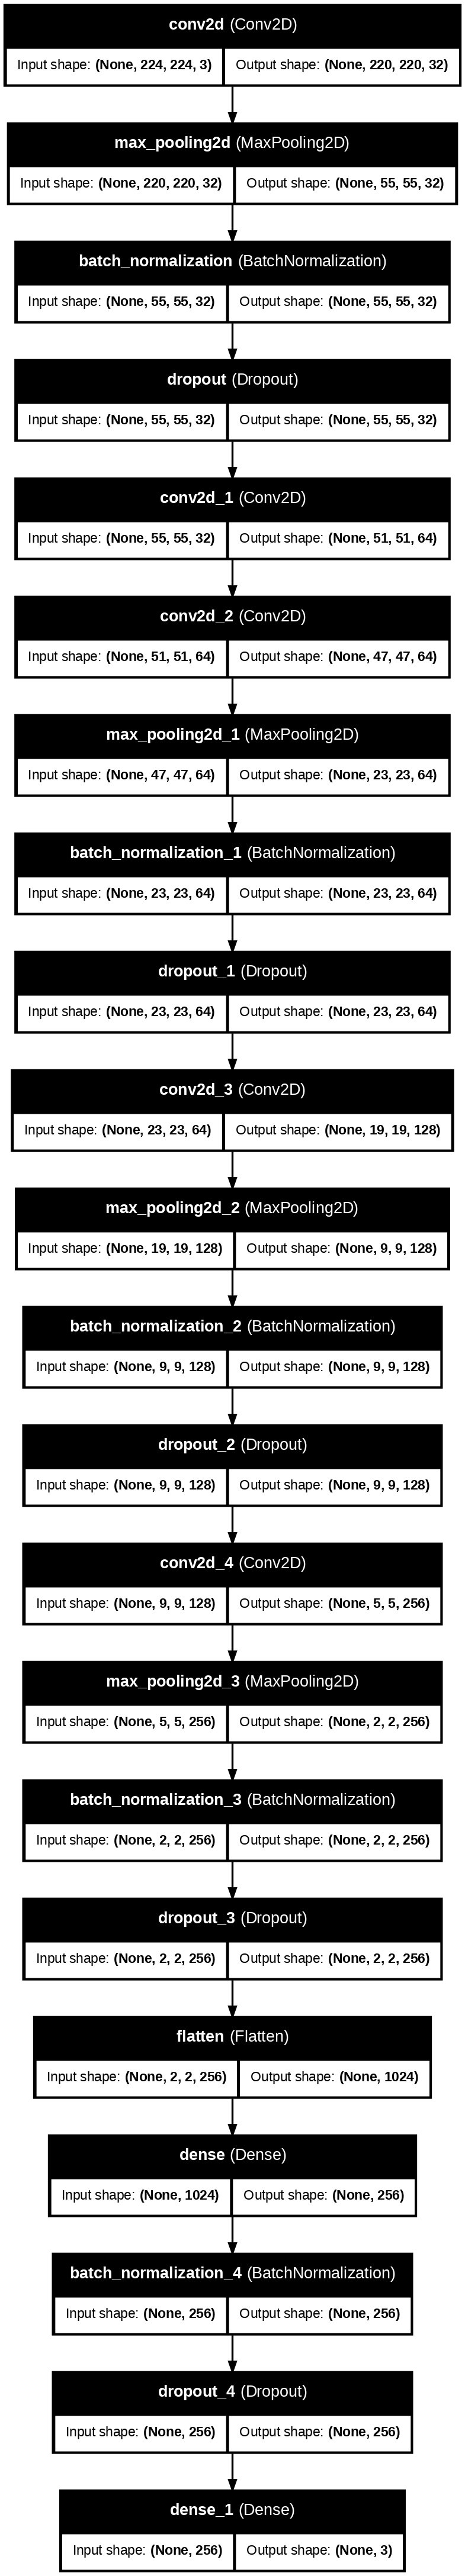

✅ Saved PNG: /content/model_vis/cnn_architecture.png


In [24]:
#cell 25 to visualize model architecture

import os, pathlib, subprocess, tempfile
from IPython.display import Image, SVG
from tensorflow.keras.utils import plot_model, model_to_dot

def has_dot():
    try:
        subprocess.run(["dot","-V"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
        return True
    except Exception:
        return False

# Use relative path for output
out_dir = PROJECT_ROOT / "model_vis"
try:
    out_dir.mkdir(exist_ok=True)
except Exception:
    out_dir = pathlib.Path(tempfile.mkdtemp(prefix="model_vis_"))
    print(f"⚠️ Using temp dir: {out_dir}")

model.summary()

if has_dot():
    png_path = out_dir / "cnn_architecture.png"
    plot_model(model, to_file=str(png_path), show_shapes=True, show_layer_names=True, dpi=120)
    display(Image(filename=str(png_path)))
    print(f"✅ Saved PNG: {png_path}")
else:
    try:
        svg = model_to_dot(model, show_shapes=True, show_layer_names=True).create(prog='dot', format='svg')
        display(SVG(svg))
        print("✅ Displayed SVG (Graphviz python binding only).")
    except Exception as e:
        print("⚠️ Graph rendering failed, ASCII fallback.\nReason:", e)
        for i,l in enumerate(model.layers):
            try:
                print(f"{i:02d} {l.name:25s} {l.output_shape} params={l.count_params()}")
            except:
                pass


In [25]:

 model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 51, 51, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 23, 23, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 19, 19, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 9, 9, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 5, 5, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2, 2, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,446,659 (5.52 MB)

 Trainable params: 1,445,187 (5.51 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [26]:
# cell 26 to compile the model
model.compile(optimizer='Adam',
            loss='sparse_categorical_crossentropy',
             metrics=["accuracy"])

In [27]:
# cell 27 - 5-Fold Stratified Cross-Validation Training

from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import clone_model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import numpy as np

# Create models directory
models_dir = PROJECT_ROOT / "saved_models"
models_dir.mkdir(exist_ok=True)

# Define 5-Fold Cross Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
acc_per_fold = []
loss_per_fold = []

# Variables to track the best model across folds
best_val_acc = 0
best_model_path = ""
best_history = None

print("✅ Starting 5-Fold Cross-Validation...")

for train_index, val_index in kfold.split(xtrain, ytrain):
    print(f'\n------------------------------------------------------------------------')
    print(f'Training for Fold {fold_no} ...')

    # Split data for this fold
    X_train_fold, X_val_fold = xtrain[train_index], xtrain[val_index]
    Y_train_fold, Y_val_fold = ytrain[train_index], ytrain[val_index]

    # Clone the model architecture (fresh weights for each fold)
    fold_model = clone_model(model)

    # Compile the refreshed model
    fold_model.compile(optimizer='Adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=["accuracy"])

    # Checkpoint path for this fold (native Keras format)
    fold_model_path = models_dir / f'best_model_fold_{fold_no}.keras'

    # Callbacks for this fold
    callbacks = [
        ModelCheckpoint(
            filepath=str(fold_model_path),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # Train the model
    history = fold_model.fit(
        X_train_fold, Y_train_fold,
        epochs=60,
        batch_size=32,
        verbose=1,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=callbacks
    )

    # Generate generalization metrics
    scores = fold_model.evaluate(X_val_fold, Y_val_fold, verbose=0)
    print(f'Score for fold {fold_no}: {fold_model.metrics_names[0]} of {scores[0]}; {fold_model.metrics_names[1]} of {scores[1]*100}%')
    acc_per_fold.append(scores[1] * 100)
    loss_per_fold.append(scores[0])

    # Check if this is the best model so far
    if scores[1] > best_val_acc:
        best_val_acc = scores[1]
        best_model_path = fold_model_path
        best_history = history
        print(f"New best model found at Fold {fold_no} with Val Acc: {best_val_acc*100:.2f}%")

    fold_no += 1

# == Final Results ==
print('\n------------------------------------------------------------------------')
print('Score per fold')
for i in range(0, len(acc_per_fold)):
    print(f'> Fold {i+1} - Loss: {loss_per_fold[i]:.4f} - Accuracy: {acc_per_fold[i]:.2f}%')
print('------------------------------------------------------------------------')
print('Average scores for all folds:')
print(f'> Accuracy: {np.mean(acc_per_fold):.2f}% (+- {np.std(acc_per_fold):.2f})')
print(f'> Loss: {np.mean(loss_per_fold):.4f}')
print('------------------------------------------------------------------------')

# Load best model for downstream evaluation (XAI, plots, etc.)
if best_model_path:
    print(f"Loading best model from {best_model_path} for final evaluation...")
    model = load_model(best_model_path)
    r = best_history

    # Save the overall best model
    model.save(models_dir / 'brain_tumor_best_model.keras')
    print("Best CV model saved as 'brain_tumor_best_model.keras'")
else:
    print("Warning: No best model found.")

✅ Starting 5-Fold Cross-Validation...

------------------------------------------------------------------------
Training for Fold 1 ...
Epoch 1/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5728 - loss: 1.6740
Epoch 1: val_accuracy improved from -inf to 0.33301, saving model to /content/saved_models/best_model_fold_1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.5733 - loss: 1.6720 - val_accuracy: 0.3330 - val_loss: 11.6097 - learning_rate: 0.0010
Epoch 2/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7578 - loss: 1.0571
Epoch 2: val_accuracy improved from 0.33301 to 0.57184, saving model to /content/saved_models/best_model_fold_1.keras
129/129 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.7579 - loss: 1.0566 - val_accuracy: 0.5718 - val_loss: 2.1431 - learning_rate: 0.0010
Epoch 3/60
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.8102 - loss: 0.8867
Epoch 3: val_accuracy improved from 0.57184 to 0.70680, saving model to /conte

In [28]:
 # cell 28 to plot the loss and accuracy curves
 def plot_loss_curves_mplt(history,

                          fill_a=0,
                          with_best_point=False,
                          plt_style="seaborn-v0_8-whitegrid",
                          start_epoch=1,
                          figsize = (20, 8)
                          ):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]


    accuracy = history.history["accuracy"]

    val_accuracy = history.history["val_accuracy"]


    epochs = range(start_epoch, len(history.history["loss"])+1)

    index_loss = np.argmin(val_loss)  # This is the epoch with the lowest validation loss
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_accuracy)
    acc_highest = val_accuracy[index_acc]

    sc_label = 'Best epoch = ' + str(index_loss + start_epoch)
    vc_label = 'Best epoch = ' + str(index_acc + start_epoch)

    plt.figure(figsize=figsize, facecolor='white')
    plt.style.use(plt_style)

    # Plot loss
    plt.subplot(1, 2, 1)
    ax1 = plt.gca()  # Get the current axis
    ax1.plot(epochs, loss, '#008000', label='Training loss', linewidth=4)
    ax1.plot(epochs, val_loss,  "#FE0000", label='Validation loss', linewidth=4)
    if fill_a:
        ax1.fill_between(epochs, val_loss, loss, color='gray', alpha=fill_a)
    ax1.set_title("Training and Validation Loss", fontsize=20)
    ax1.set_xlabel("Epochs", fontsize=20)
    ax1.set_ylabel("Loss", fontsize=20)
    ax1.set_xlim([0.5, len(epochs)])
    # Plot best point
    if with_best_point:
        ax1.scatter(index_loss + start_epoch, val_lowest, s=150, c='blue', label=sc_label)
    ax1.legend(fontsize=18, loc='upper right', frameon=False)

    # Plot accuracy
    plt.subplot(1, 2, 2)
    ax2 = plt.gca()  # Get the current axis
    ax2.plot(epochs, accuracy, '#008000',  label='Training Accuracy', linewidth=4)
    ax2.plot(epochs, val_accuracy,"#FE0000", label='Validation Accuracy', linewidth=4)
    if fill_a:
        ax2.fill_between(epochs, val_accuracy, accuracy, color='gray', alpha=fill_a)
    ax2.set_title("Training and Validation Accuracy", fontsize=20)
    ax2.set_xlabel("Epochs", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_xlim([0.5, len(epochs)])
    ax2.set_ylim([0, 1.1])
    # Plot best point
    if with_best_point:
        ax2.scatter(index_acc + start_epoch, acc_highest, s=150, c='blue', label=vc_label)
    ax2.legend(fontsize=18, loc='lower right', frameon=False)

    plt.tight_layout()
    plt.show()

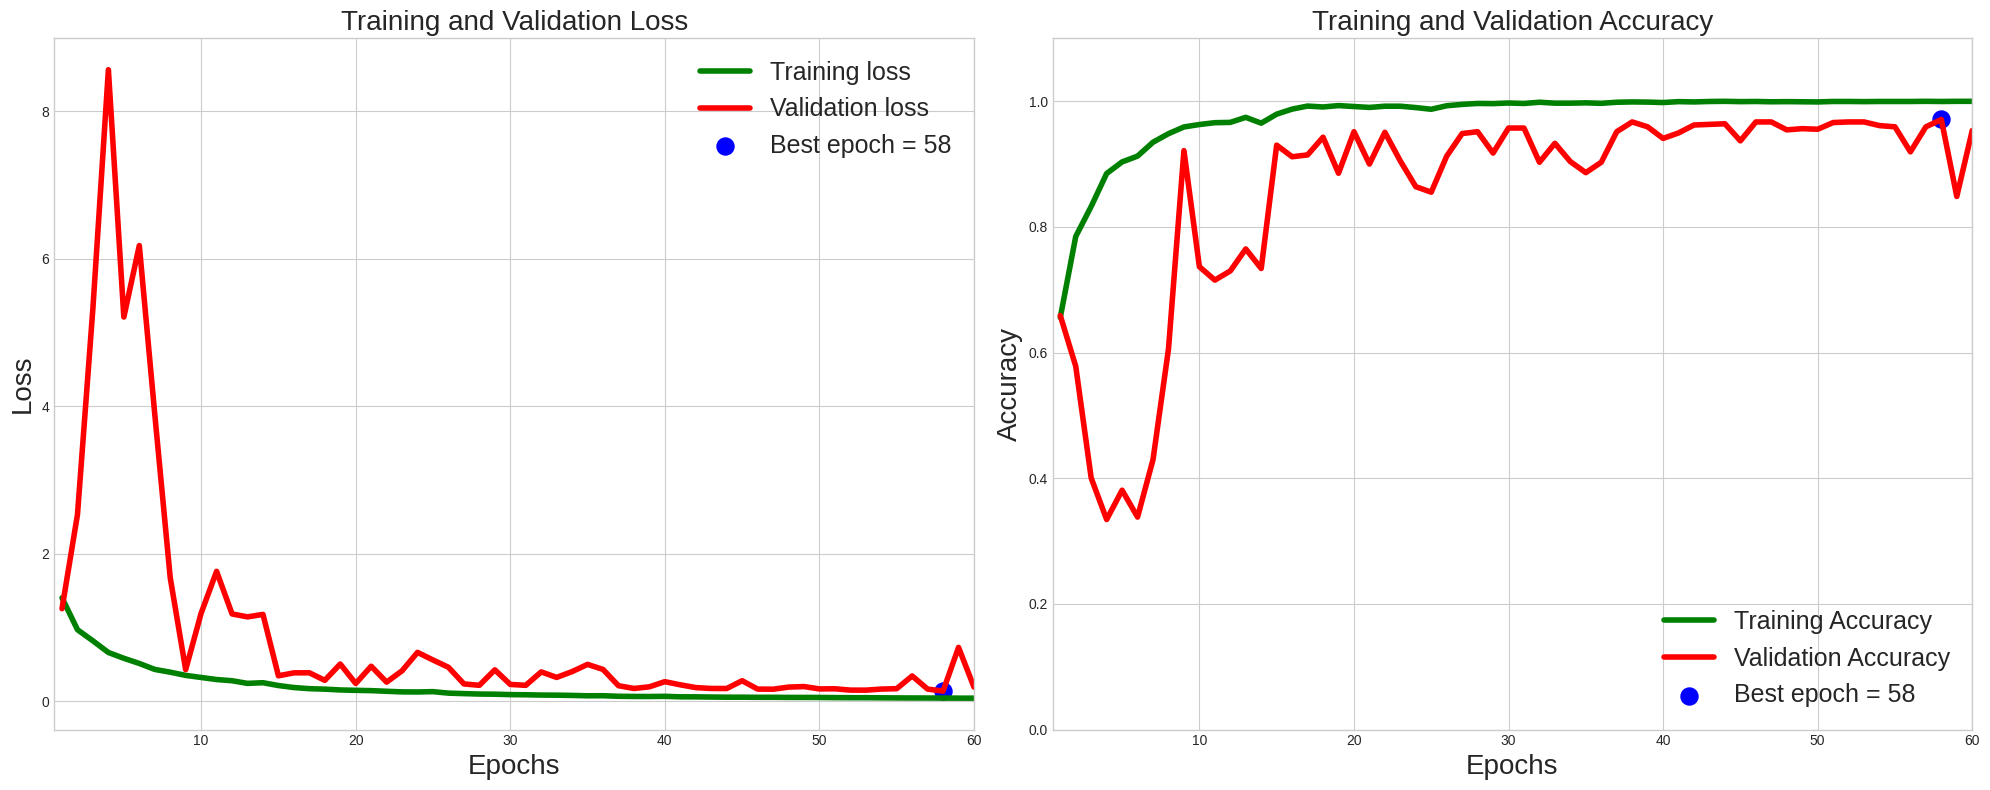

In [29]:
# cell 29 to plot the loss and accuracy curves
plot_loss_curves_mplt(r, with_best_point=True)

In [30]:
# cell 30 to make predictions
pred=model.predict(xtest)
Y_pred = np.argmax(pred, 1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


In [31]:
# cell 31 to check the shape of predictions
Y_pred.shape


(909,)

In [32]:
# cell 32 to check the shape of actual test labels
ytest.shape

(909,)

In [33]:
# cell 33 to evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
print('Confusion Matrix')
print(confusion_matrix(ytest, Y_pred))

Confusion Matrix
[[291   9   1]
 [  7 284  10]
 [  0   1 306]]


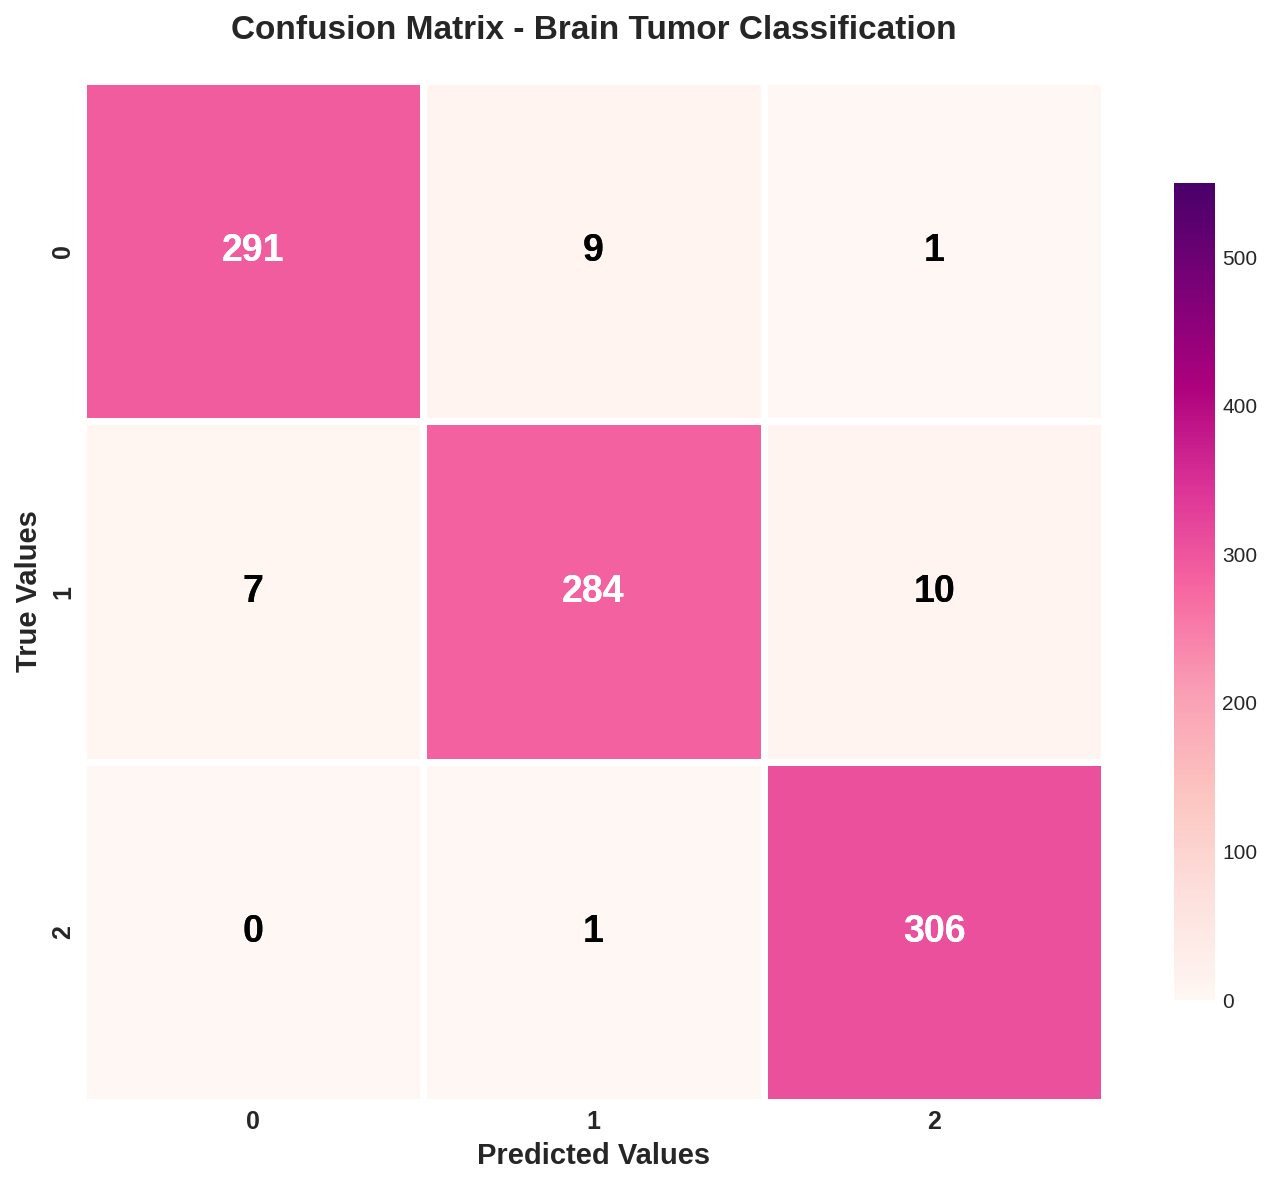

In [34]:
# cell 34 to print classification report
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(ytest, Y_pred)
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with dark background colors for better contrast
sns.heatmap(cm, square=True, annot=True, fmt="d", cbar=True,
            cmap='RdPu',  # Red-Purple theme - better contrast
            annot_kws={"size": 18, "weight": "bold"},
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=550)  # Set consistent scale

# Manually add white text on dark cells for perfect visibility
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        # Use white text for values > 100, black for smaller values
        text_color = 'white' if value > 100 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center',
                fontsize=18, weight='bold', color=text_color)

plt.xlabel('Predicted Values', fontsize=14, weight='bold')
plt.ylabel('True Values', fontsize=14, weight='bold')
plt.title('Confusion Matrix - Brain Tumor Classification', fontsize=16, weight='bold', pad=20)
plt.xticks(fontsize=12, weight='bold')
plt.yticks(fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

In [35]:
print('Classification Report')
target_names = ['glioma', 'meningioma', 'pituitary']
print(classification_report(ytest, Y_pred, target_names=target_names))

Classification Report
              precision    recall  f1-score   support

      glioma       0.98      0.97      0.97       301
  meningioma       0.97      0.94      0.95       301
   pituitary       0.97      1.00      0.98       307

    accuracy                           0.97       909
   macro avg       0.97      0.97      0.97       909
weighted avg       0.97      0.97      0.97       909



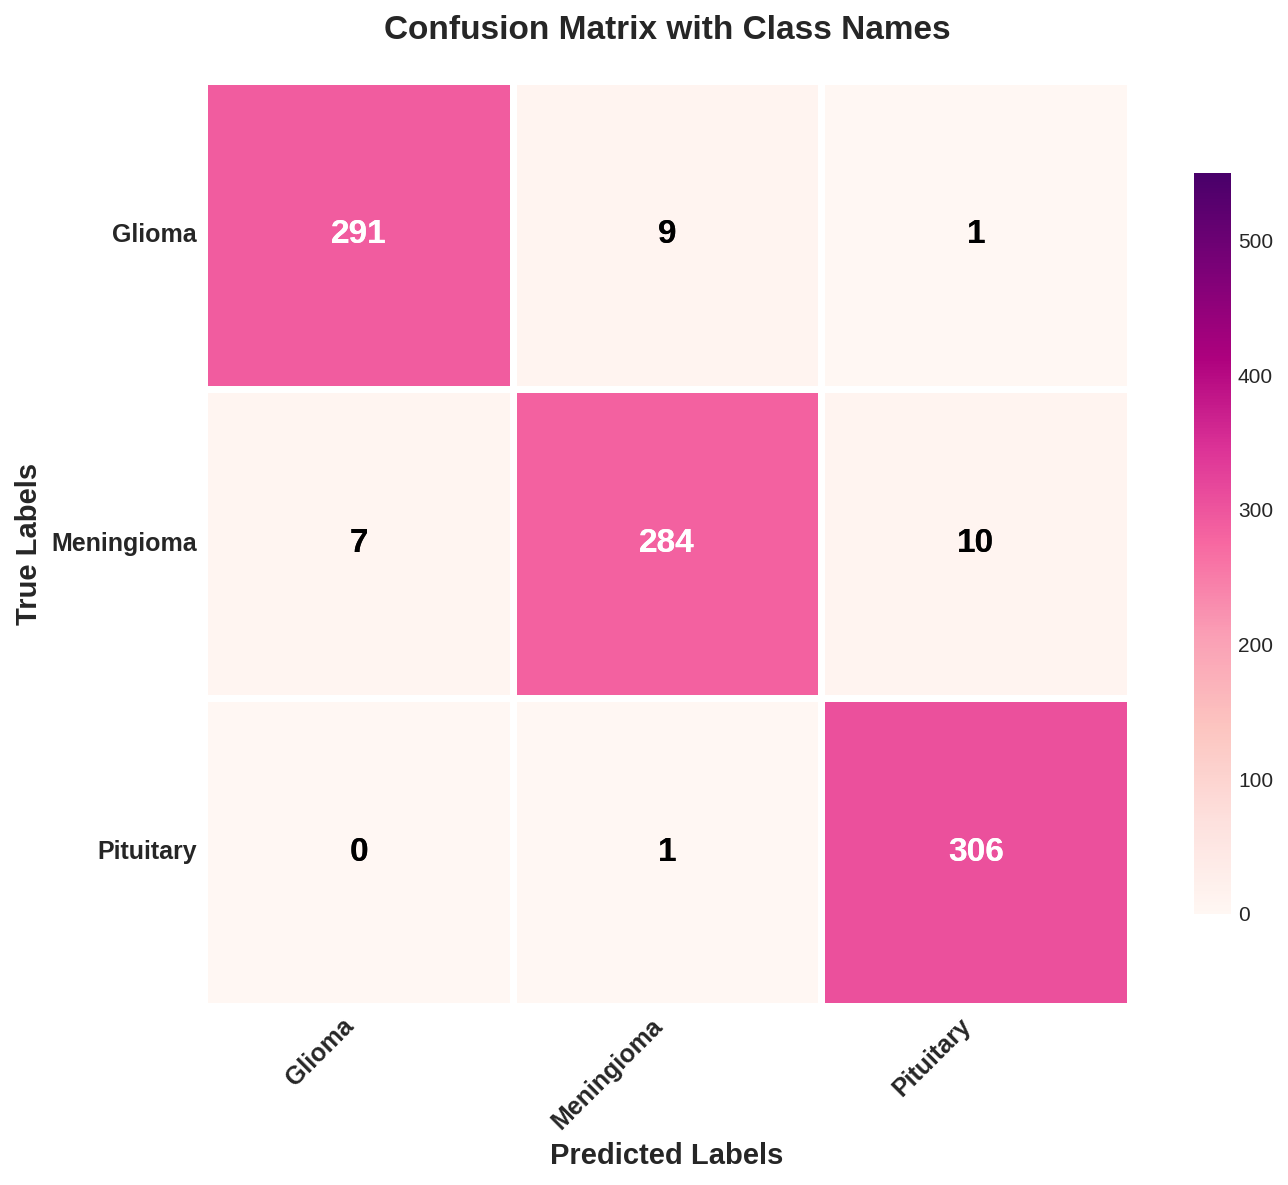

In [36]:
# cell 36 to plot confusion matrix with labels
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with proper size
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with RdPu theme matching Cell 34
sns.heatmap(cm, square=True, annot=True, fmt="d", cbar=True,
            cmap='RdPu',
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=550)

# Add adaptive text colors for better visibility
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        text_color = 'white' if value > 100 else 'black'
        plt.text(j + 0.5, i + 0.5, str(value),
                ha='center', va='center',
                fontsize=16, weight='bold', color=text_color)

# Set class name labels on axes
plt.xlabel('Predicted Labels', fontsize=14, weight='bold')
plt.ylabel('True Labels', fontsize=14, weight='bold')
plt.title('Confusion Matrix with Class Names', fontsize=16, weight='bold', pad=20)

# Apply class names to tick labels
plt.xticks(ticks=[0.5, 1.5, 2.5],
           labels=['Glioma', 'Meningioma', 'Pituitary'],
           fontsize=12, weight='bold', rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5, 2.5],
           labels=['Glioma', 'Meningioma', 'Pituitary'],
           fontsize=12, weight='bold', rotation=0)

plt.tight_layout()
plt.show()

Confusion Matrix :
[[291   9   1]
 [  7 284  10]
 [  0   1 306]]

Accuracy Score : 0.9691969196919692

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       301
           1       0.97      0.94      0.95       301
           2       0.97      1.00      0.98       307

    accuracy                           0.97       909
   macro avg       0.97      0.97      0.97       909
weighted avg       0.97      0.97      0.97       909



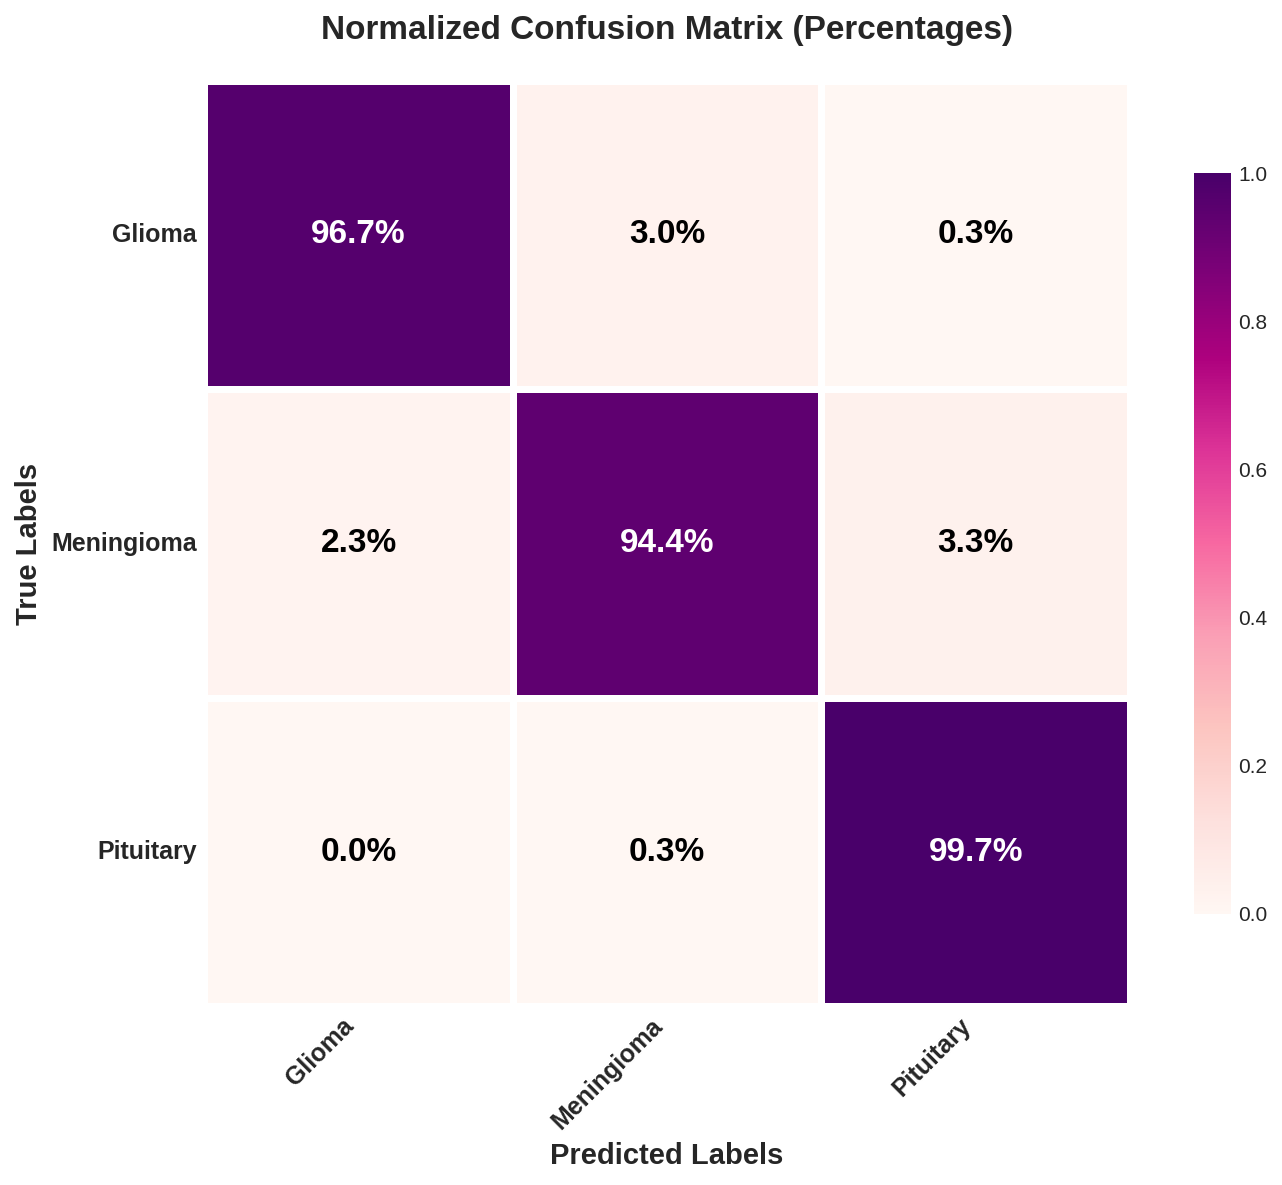

In [37]:
# cell 37 to plot normalized confusion matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

results = confusion_matrix(ytest, Y_pred)

# Print text summary
print('Confusion Matrix :')
print(results)
print('\nAccuracy Score :', accuracy_score(ytest, Y_pred))
print('\nClassification Report :')
print(classification_report(ytest, Y_pred))

# Create normalized confusion matrix (percentages)
results_normalized = results.astype('float') / results.sum(axis=1)[:, np.newaxis]

# Create figure with proper size
plt.figure(figsize=(10, 8), dpi=150)

# Create heatmap with RdPu theme - annot=False to avoid duplication
sns.heatmap(results_normalized, square=True, annot=False, fmt='.1%',
            cbar=True, cmap='RdPu',
            linewidths=2.5, linecolor='white',
            cbar_kws={"shrink": 0.8},
            vmin=0, vmax=1.0)

# Manually add text with adaptive colors (only once!)
for i in range(results_normalized.shape[0]):
    for j in range(results_normalized.shape[1]):
        value = results_normalized[i, j]
        text = f'{value:.1%}'
        text_color = 'white' if value > 0.5 else 'black'
        plt.text(j + 0.5, i + 0.5, text,
                ha='center', va='center',
                fontsize=16, weight='bold', color=text_color)

# Set labels
plt.xlabel('Predicted Labels', fontsize=14, weight='bold')
plt.ylabel('True Labels', fontsize=14, weight='bold')
plt.title('Normalized Confusion Matrix (Percentages)', fontsize=16, weight='bold', pad=20)

# Apply class names to tick labels
plt.xticks(ticks=[0.5, 1.5, 2.5],
           labels=['Glioma', 'Meningioma', 'Pituitary'],
           fontsize=12, weight='bold', rotation=45, ha='right')
plt.yticks(ticks=[0.5, 1.5, 2.5],
           labels=['Glioma', 'Meningioma', 'Pituitary'],
           fontsize=12, weight='bold', rotation=0)

plt.tight_layout()
plt.show()

In [38]:
# cell 38 to compute ROC AUC for multi-class classification
import numpy as np
from sklearn import metrics
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output for multi-class ROC
y_test_bin = label_binarize(ytest, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

# pred variable is assumed to be the output of model.predict(xtest) from earlier cell
# Ensure pred has the correct shape for multi-class (it should be probabilities)
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), pred.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

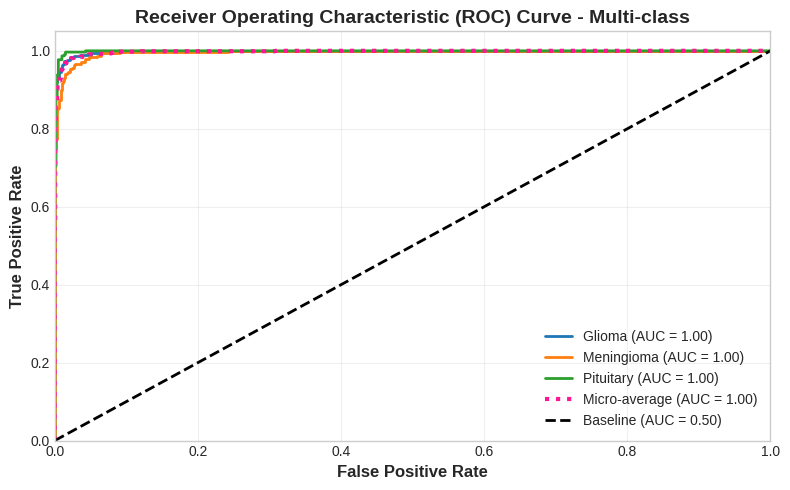

In [39]:
# cell 39 to plot ROC AUC curve
import matplotlib.pyplot as plt

# Define inv_classes for use in later cells (XAI, GradCAM)
if 'classes' in locals():
    inv_classes = {v: k for k, v in classes.items()}
else:
    # Fallback default for 3-class setup
    inv_classes = {0: 'glioma', 1: 'meningioma', 2: 'pituitary'}

fig, ax = plt.subplots(figsize=(8, 5))

# Plot ROC curve for each class
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # 3 colors
class_names = ['Glioma', 'Meningioma', 'Pituitary'] # 3 classes

# Ensure n_classes is correct based on actual data
n_classes = len(class_names)

for i, color in zip(range(n_classes), colors):
    if i in roc_auc:
        ax.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

# Plot micro-average ROC curve
if "micro" in roc_auc:
    ax.plot(fpr["micro"], tpr["micro"],
            label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})',
            color='deeppink', linestyle=':', linewidth=3)

# Plot baseline (random classifier)
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Baseline (AUC = 0.50)')

# Formatting
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Receiver Operating Characteristic (ROC) Curve - Multi-class', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

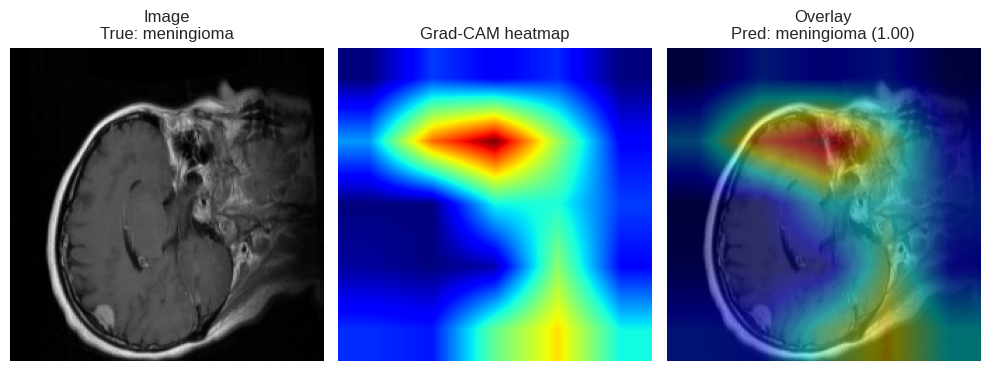

In [40]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt

def get_last_conv_layer_name(m):
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

def gradcam_heatmap_bgr(img_bgr, model, layer_name=None, class_index=None):
    """
    img_bgr: HxWx3 BGR uint8/float32 (same scale as training)
    returns: heatmap (HxW, 0..1), probs (model softmax output)
    """
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)

    x = img_bgr.astype(np.float32)  # keep original magnitude (no /255)
    x = np.expand_dims(x, axis=0)  # Add batch dimension

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        # Manually perform forward pass through the model's layers
        # to get the intermediate conv_out and the final predictions.
        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            # Ensure training=False is passed for layers like BatchNormalization and Dropout
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out) # Watch conv_out right after its computation

        preds = current_output # current_output now holds the final predictions

        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    # Check if grads is None and handle if necessary (though this fix aims to prevent it)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. This indicates a problem in the gradient computation path.")

    weights = tf.reduce_mean(grads, axis=(0, 1, 2))  # GAP over H,W

    cam = tf.tensordot(conv_out[0], weights, axes=[[2], [0]])
    cam = tf.maximum(cam, 0)  # ReLU
    cam = cam.numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

def overlay_gradcam_bgr(img_bgr, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    hm = np.uint8(255 * np.clip(heatmap, 0, 1))
    hm_color = cv2.applyColorMap(hm, colormap)  # BGR
    base = img_bgr.astype(np.float32) / 255.0
    hm_f = hm_color.astype(np.float32) / 255.0
    overlay = (1 - alpha) * base + alpha * hm_f
    overlay = np.clip(overlay * 255.0, 0, 255).astype(np.uint8)
    # Convert to RGB for matplotlib display
    return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# ---- Demo on a test sample ----
test_idx = 0  # change to inspect other images
img_bgr = xtest[test_idx]  # model was trained on BGR from cv2

last_conv = get_last_conv_layer_name(model)
heatmap, probs = gradcam_heatmap_bgr(img_bgr, model, layer_name=last_conv, class_index=None)
overlay_rgb = overlay_gradcam_bgr(img_bgr, heatmap, alpha=0.45)

pred_id = int(np.argmax(probs))
true_id = int(ytest[test_idx])

# Try to use your existing inv_classes mapping if available
try:
    pred_name = inv_classes[pred_id]
    true_name = inv_classes[true_id]
except Exception:
    pred_name = str(pred_id)
    true_name = str(true_id)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title(f"Image\nTrue: {true_name}")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay_rgb)
plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})")
plt.axis('off')

plt.tight_layout()
plt.show()

Conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']


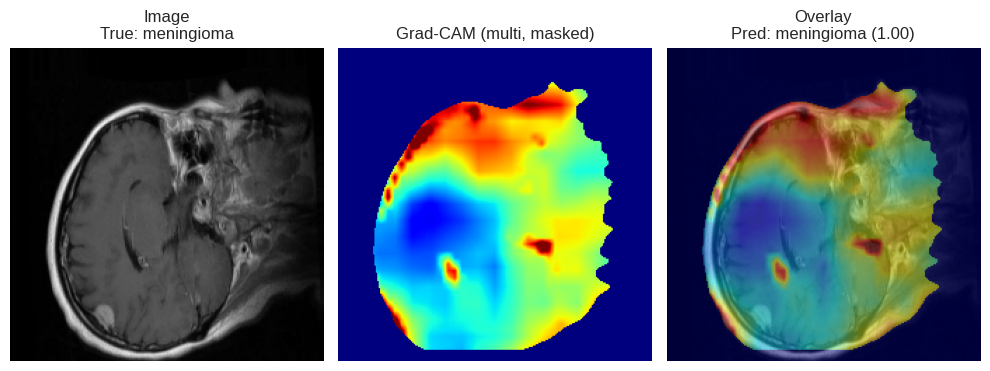

In [41]:
# cell 41 - Multi-layer Grad-CAM with brain mask and robust normalization

import numpy as np, tensorflow as tf, cv2, matplotlib.pyplot as plt

# 1) List conv layers
def list_conv_layers(m):
    return [l.name for l in m.layers if isinstance(l, tf.keras.layers.Conv2D)]

# Helper: auto-detect image scale ([0,1] or [0,255])
def _to_uint8(img):
    """Convert image to uint8 regardless of input scale."""
    if img.max() <= 1.0 + 1e-3:
        return (img * 255).astype(np.uint8)
    return img.astype(np.uint8)

def _to_float01(img):
    """Convert image to float32 [0,1] regardless of input scale."""
    f = img.astype(np.float32)
    if f.max() > 1.0 + 1e-3:
        f = f / 255.0
    return f

# 2) Brain mask (auto-handles both [0,1] and [0,255] images)
def brain_mask_fn(img):
    """img: HxWx3 BGR, any scale. Returns binary mask (0/1 uint8)."""
    img_uint8 = _to_uint8(img)
    g = cv2.cvtColor(img_uint8, cv2.COLOR_BGR2GRAY)
    g = cv2.GaussianBlur(g, (7,7), 0)
    _, th = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, k, iterations=2)
    cnts,_ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    m = np.zeros_like(th, dtype=np.uint8)
    if cnts:
        c = max(cnts, key=cv2.contourArea)
        cv2.drawContours(m, [c], -1, 255, -1)
    return (m > 0).astype(np.uint8)

# 3) Grad-CAM for a single conv layer
def gradcam_for_layer(img, model, layer_name, class_index=None):
    x = img.astype(np.float32)
    x = np.expand_dims(x, 0)

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out)
        preds = current_output

        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}.")

    weights = tf.reduce_mean(grads, axis=(0,1,2))
    cam = tf.tensordot(conv_out[0], weights, axes=[[2],[0]])
    cam = tf.maximum(cam, 0).numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

# 4) Robust normalization inside brain mask + border trim
def normalize_inside_mask(hm, mask, percentile=99, border_trim=8):
    h = hm.copy().astype(np.float32)
    if mask is not None and mask.any():
        vals = h[mask > 0]
        if vals.size > 0:
            hi = np.percentile(vals, percentile)
            if hi > 0: h = np.clip(h / hi, 0, 1)
    else:
        hi = np.percentile(h, percentile)
        if hi > 0: h = np.clip(h / hi, 0, 1)
    if border_trim > 0:
        h[:border_trim,:] = 0; h[-border_trim:,:] = 0
        h[:,:border_trim] = 0; h[:,-border_trim:] = 0
    if h.max() > 0:
        h = (h - h.min()) / (h.max() - h.min() + 1e-8)
    return h

# 5) Multi-layer Grad-CAM blend
def multilayer_gradcam(img, model, layers=None, class_index=None,
                       use_mask=True, percentile=99, border_trim=8):
    if layers is None:
        convs = list_conv_layers(model)
        layers = convs[-3:] if len(convs) >= 3 else convs
    maps = []
    probs_ref = None
    for ln in layers:
        hm, probs = gradcam_for_layer(img, model, ln, class_index)
        maps.append(hm)
        probs_ref = probs
    ws = np.linspace(1.0, 0.7, num=len(maps)).astype(np.float32)
    ws /= ws.sum()
    combo = np.zeros_like(maps[0], dtype=np.float32)
    for w, m in zip(ws, maps): combo += w * m
    mask = brain_mask_fn(img) if use_mask else None
    if mask is not None: combo *= mask
    combo = normalize_inside_mask(combo, mask, percentile=percentile, border_trim=border_trim)
    return combo, probs_ref

# 6) Overlay utility (auto-handles both [0,1] and [0,255] images)
def overlay_fn(img, heatmap, alpha=0.45, colormap=cv2.COLORMAP_JET):
    """img: HxWx3 BGR (any scale), returns RGB uint8 for matplotlib display."""
    hm = np.uint8(255 * np.clip(heatmap, 0, 1))
    hm_color = cv2.applyColorMap(hm, colormap).astype(np.float32) / 255.0
    base = _to_float01(img)  # always convert to [0,1]
    ov = np.clip((1 - alpha) * base + alpha * hm_color, 0, 1)
    return cv2.cvtColor((ov * 255).astype(np.uint8), cv2.COLOR_BGR2RGB)

# ---- Example usage ----
class_names = ['glioma', 'meningioma', 'pituitary']

def show_xai(sample_idx=0, layers=None, use_mask=True):
    img = xtest[sample_idx]
    heat, probs = multilayer_gradcam(img, model, layers=layers, class_index=None,
                                     use_mask=use_mask, percentile=99, border_trim=8)
    ov = overlay_fn(img, heat, alpha=0.45)
    pred_id = int(np.argmax(probs)); true_id = int(ytest[sample_idx])
    pred_name = class_names[pred_id] if pred_id < len(class_names) else str(pred_id)
    true_name = class_names[true_id] if true_id < len(class_names) else str(true_id)

    # Convert BGR to RGB for display (auto-handle scale)
    img_rgb = cv2.cvtColor(_to_uint8(img), cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title(f"Image\nTrue: {true_name}"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(heat, cmap='jet'); plt.title("Grad-CAM (multi, masked)"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(ov); plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})"); plt.axis('off')
    plt.tight_layout(); plt.show()

print("Conv layers:", list_conv_layers(model))
show_xai(sample_idx=0, layers=None, use_mask=True)

In [42]:
# cell 42 - Grad-CAM++ core (returns heatmap 0..1 and softmax probs)

import numpy as np, tensorflow as tf, cv2

def get_last_conv_layer_name(m):
    for layer in reversed(m.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in model.")

def gradcampp_heatmap_bgr(img_bgr, model, layer_name=None, class_index=None):
    """
    Grad-CAM++ (Chattopadhyay et al.)
    img_bgr: HxWx3 BGR in the same scale as training (here 0..255)
    returns: (heatmap 0..1, probs vector)
    """
    if layer_name is None:
        layer_name = get_last_conv_layer_name(model)

    x = img_bgr.astype(np.float32)[None, ...]

    with tf.GradientTape() as tape:
        input_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
        tape.watch(input_tensor)

        current_output = input_tensor
        conv_out = None

        for layer in model.layers:
            current_output = layer(current_output, training=False)
            if layer.name == layer_name:
                conv_out = current_output
                tape.watch(conv_out)  # Watch conv_out right after its computation
        preds = current_output  # current_output now holds the final predictions

        if class_index is None:
            class_index = tf.cast(tf.argmax(preds[0]), tf.int32)
        score = preds[:, class_index]

    grads  = tape.gradient(score, conv_out)
    # Check if grads is None and handle if necessary
    if grads is None:
        raise ValueError(f"Gradients are None for layer {layer_name}. This indicates a problem in the gradient computation path.")

    grads2 = tf.square(grads)
    grads3 = grads2 * grads
    conv_relu = tf.nn.relu(conv_out)

    eps = 1e-10
    alpha_num    = grads2
    alpha_denom = 2.0*grads2 + conv_relu*grads3 + eps
    alpha = alpha_num / alpha_denom                                  # (1,H,W,C)

    weights = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2))   # (1,C)

    cam = tf.reduce_sum(weights[:, None, None, :] * conv_relu, axis=-1)[0]  # (H,W)
    cam = tf.maximum(cam, 0).numpy()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (img_bgr.shape[1], img_bgr.shape[0]), interpolation=cv2.INTER_LINEAR)
    return cam, preds.numpy()[0]

Conv layers: ['conv2d', 'conv2d_1', 'conv2d_2', 'conv2d_3', 'conv2d_4']


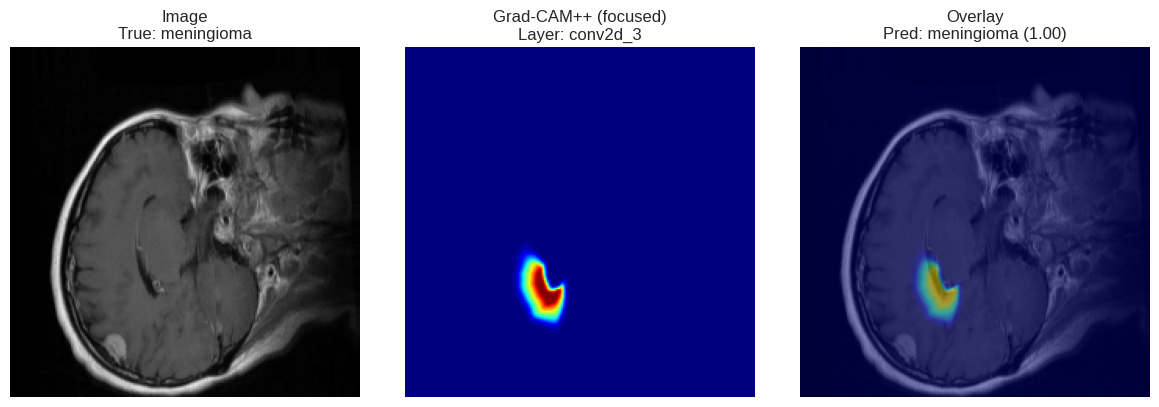

In [43]:
# cell 43 - Grad-CAM++ focused v4 (deep-core focus + hemisphere gate + component filter)

import numpy as np, cv2, matplotlib.pyplot as plt

def mirror_about_midline(arr, mask):
    H, W = arr.shape
    ys, xs = np.indices((H, W))
    x_in = xs[mask>0]
    if x_in.size == 0:
        return np.zeros_like(arr, dtype=arr.dtype)
    cx = float(x_in.mean())
    j2 = np.round(2*cx - xs).astype(np.int32)
    inside = (j2 >= 0) & (j2 < W)
    mir = np.zeros_like(arr, dtype=arr.dtype)
    mir[inside] = arr[ys[inside], j2[inside]]
    return mir

def boundary_core_masks(mask, thickness=20):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    core = cv2.erode(mask.astype(np.uint8), k, iterations=1)
    cortical = (mask.astype(np.uint8) - core).astype(np.uint8)
    return core, cortical

def keep_dominant_component(hm, mask, min_area=60, open_ks=3, thr_pct=94):
    if not mask.any():
        return hm
    vals = hm[mask>0]
    if vals.size == 0:
        return hm
    thr = np.percentile(vals, thr_pct)
    bw = ((hm >= thr) & (mask>0)).astype(np.uint8)
    if open_ks and open_ks>1:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ks, open_ks))
        bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, k, iterations=1)
    cnts, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return hm
    H, W = hm.shape
    best = None
    for c in cnts:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x,y,w,h = cv2.boundingRect(c)
        per = max(cv2.arcLength(c, True), 1e-6)
        circ = (4.0*np.pi*area)/(per*per)
        ar = min(w,h)/max(w,h)
        extent = area / float(max(w*h,1))
        cmask = np.zeros((H,W), np.uint8); cv2.drawContours(cmask,[c],-1,1,-1)
        mean_h = float(hm[cmask>0].mean()) if cmask.any() else 0.0
        # penalize ribbon-like shapes (low extent, low ar), reward compactness
        score = mean_h * area * (0.5 + 0.25*ar + 0.25*circ) * (0.6 + 0.4*extent)
        if (best is None) or (score > best[0]):
            best = (score, cmask)
    if best is None:
        return hm
    keep = best[1].astype(np.float32)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    keep = cv2.dilate(keep, k, iterations=1)
    return hm * keep

def gradcampp_show(sample_idx=0, conv_name=None, percentile=97, border_trim=14,
                   alpha=0.45, save=False, cortical_th=20, rim_cut=0.43,
                   rim_power=2.6, mid_sigma=0.16, asym_gain=1.10):
    # image
    img = xtest[sample_idx]

    # use penultimate conv for semantic, high-level CAMs
    try:
        convs = list_conv_layers(model)  # from Cell 41
        if conv_name is None:
            conv_name = convs[-2] if len(convs) >= 2 else convs[-1]
    except Exception:
        conv_name = None

    # Grad-CAM++ heatmap
    hm, probs = gradcampp_heatmap_bgr(img, model, layer_name=conv_name, class_index=None)

    # brain mask + distance transform
    mask = brain_mask_fn(img)
    dt = cv2.distanceTransform((mask*255).astype(np.uint8), cv2.DIST_L2, 5).astype(np.float32)
    dt_norm = dt/(dt.max()+1e-6) if dt.max()>0 else dt

    # rim and midline suppression
    w_rim = np.clip((dt_norm - rim_cut) / max(1e-6, (1.0 - rim_cut)), 0, 1) ** rim_power
    ys, xs = np.indices(mask.shape)
    x_in = xs[mask>0]
    cx = float(x_in.mean()) if x_in.size else xs.shape[1]/2.0
    half_w = max((x_in.max()-x_in.min()) if x_in.size else xs.shape[1], 1.0)/2.0
    w_mid = 1.0 - np.exp(- (np.abs(xs-cx)/half_w)**2 / (2*(mid_sigma**2)))

    # core vs cortical weighting (favor deep core, strongly downweight cortical belt)
    core, cortical = boundary_core_masks(mask, thickness=cortical_th)
    w_coremap = (core>0).astype(np.float32)*1.0 + (cortical>0).astype(np.float32)*0.05

    # deep-core emphasis (ignore very rim-proximal areas)
    deep_core = (dt_norm > 0.45).astype(np.float32)

    # apply weights
    hm = hm * w_rim * w_mid * w_coremap * deep_core * mask

    # normalize inside mask + border trim
    hm = normalize_inside_mask(hm, mask, percentile=percentile, border_trim=border_trim)  # from Cell 41

    # brightness-guided boost inside deep core (helps ring-enhancing lesions)
    img_u8 = _to_uint8(img)  # ensure uint8 for cv2.cvtColor
    g = cv2.cvtColor(img_u8, cv2.COLOR_BGR2GRAY).astype(np.float32)
    if (mask>0).any():
        t = np.percentile(g[mask>0], 93)
        bright = ((g >= t) & (deep_core>0)).astype(np.float32)
        hm *= (0.60 + 0.40*bright)

    # strong asymmetry gating
    mir = mirror_about_midline(hm, mask)
    hm_asym = np.clip(hm - mir, 0, 1)
    hm_asym = normalize_inside_mask(hm_asym, mask, percentile=97, border_trim=border_trim)
    hm = np.clip(hm * (0.02 + asym_gain*hm_asym) * np.power(hm_asym+1e-6, 0.7), 0, 1)

    # hemisphere gating using deep-core energy
    left = (xs < cx) & (mask>0)
    right = (xs >= cx) & (mask>0)
    hL = float((hm * deep_core * left).sum())
    hR = float((hm * deep_core * right).sum())
    if hL >= hR:
        hm[right] *= 0.04
    else:
        hm[left] *= 0.04

    # keep dominant component only
    hm = keep_dominant_component(hm, mask, min_area=60, open_ks=3, thr_pct=94)

    # hard clip near-rim band
    hm[dt_norm < (rim_cut + 0.05)] *= 0.03

    # light smoothing for visuals
    hm = cv2.GaussianBlur(hm, (0,0), 0.9)

    # overlay (overlay_fn from Cell 41 auto-handles image scale)
    ov = overlay_fn(img, hm, alpha=alpha)

    # labels
    pred_id = int(np.argmax(probs))
    try:
        pred_name = inv_classes[pred_id]
        true_name = inv_classes[int(ytest[sample_idx])]
    except Exception:
        pred_name = str(pred_id); true_name = str(int(ytest[sample_idx]))

    # show (use _to_uint8 for safe BGR→RGB conversion)
    img_rgb = cv2.cvtColor(_to_uint8(img), cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title(f"Image\nTrue: {true_name}"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(hm, cmap='jet'); plt.title(f"Grad-CAM++ (focused)\nLayer: {conv_name}"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(ov); plt.title(f"Overlay\nPred: {pred_name} ({probs[pred_id]:.2f})"); plt.axis('off')
    plt.tight_layout(); plt.show()

    if save:
        import os
        out = os.path.join(os.getcwd(), "xai_outputs"); os.makedirs(out, exist_ok=True)
        base = f"idx{sample_idx}_gcapp_v4_{conv_name}_pred{pred_name}_{probs[pred_id]:.2f}"
        cv2.imwrite(os.path.join(out, base+"_overlay_rgb.png"), cv2.cvtColor(ov, cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(out, base+"_heat_uint8.png"), (hm*255).astype(np.uint8))
        print("Saved to:", out)

    return hm, ov, probs

# Example run
print("Conv layers:", list_conv_layers(model))
_ = gradcampp_show(sample_idx=0, cortical_th=20, rim_cut=0.43, rim_power=2.6, mid_sigma=0.16,
                   percentile=97, border_trim=14, alpha=0.45, save=False)

In [44]:
# cell 44 - Batch save XAI overlays

def save_xai_batch(start=0, end=12, conv=None):
    for i in range(start, min(end, len(xtest))):
        try:
            gradcampp_show(sample_idx=i, conv_name=conv, save=True)
        except Exception as e:
            print(f"Idx {i}: failed ->", e)

# Usage:
# save_xai_batch(0, 16)  # saves overlays for indices 0..15 into xai_outputs

Using output dir: /content/xai_outputs


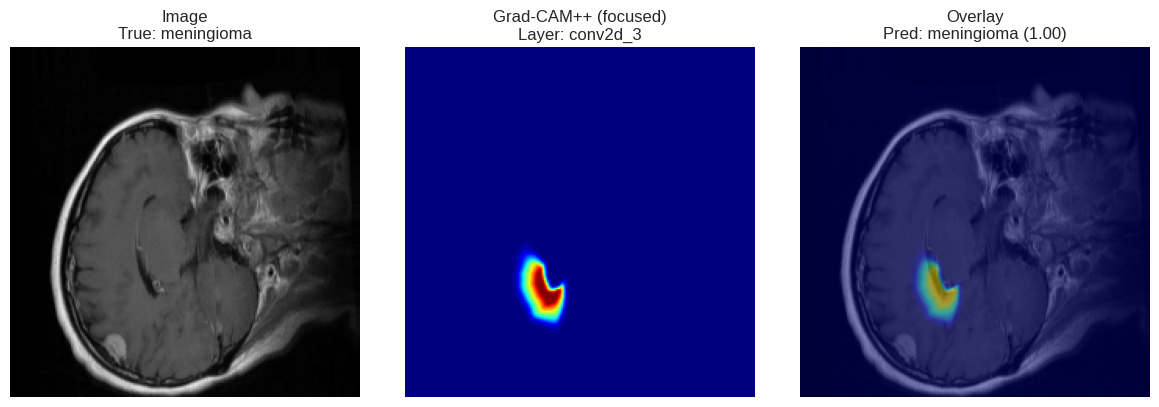

Saved to: /content/xai_outputs


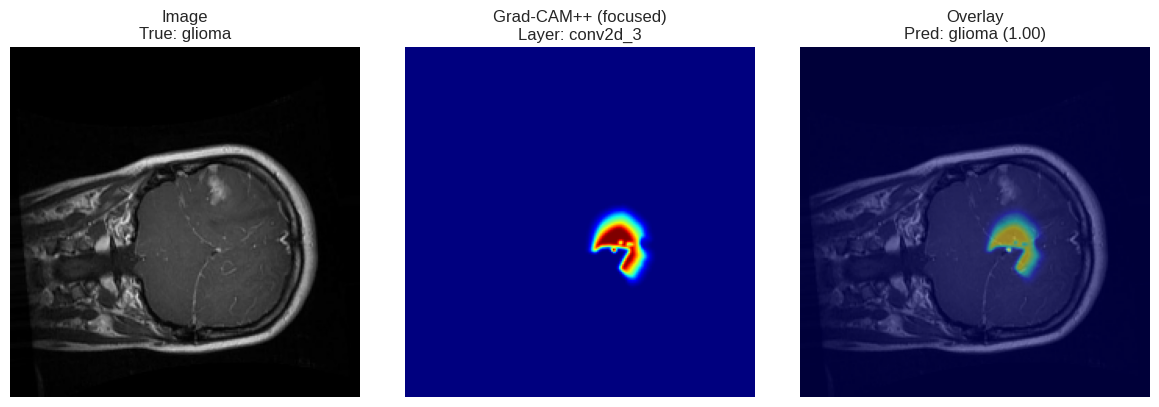

Saved to: /content/xai_outputs


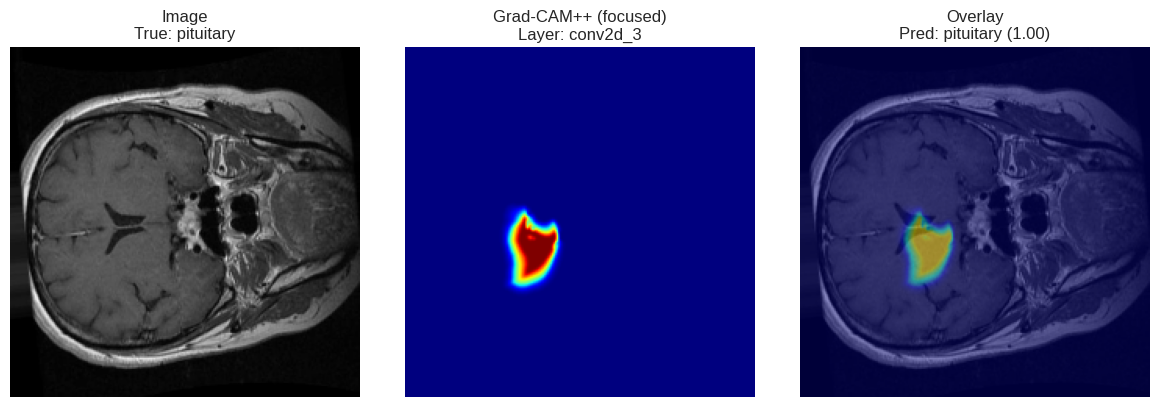

Saved to: /content/xai_outputs


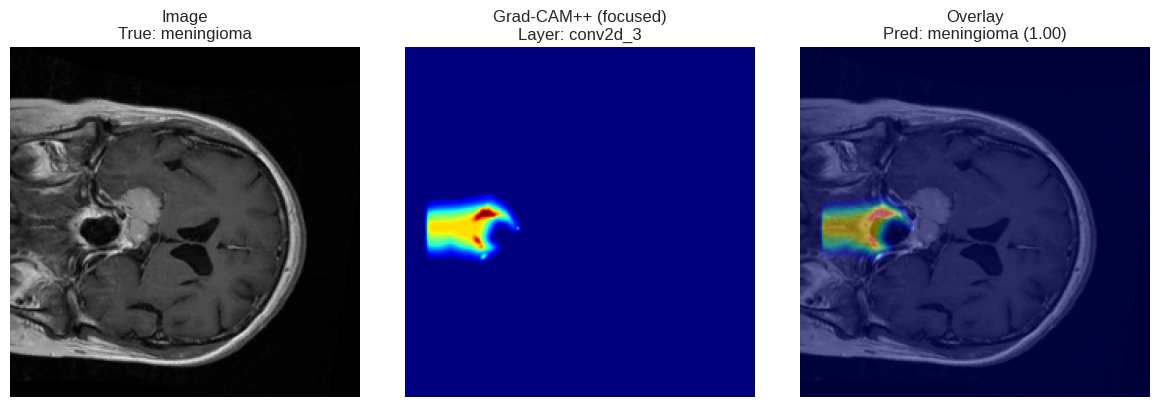

Saved to: /content/xai_outputs


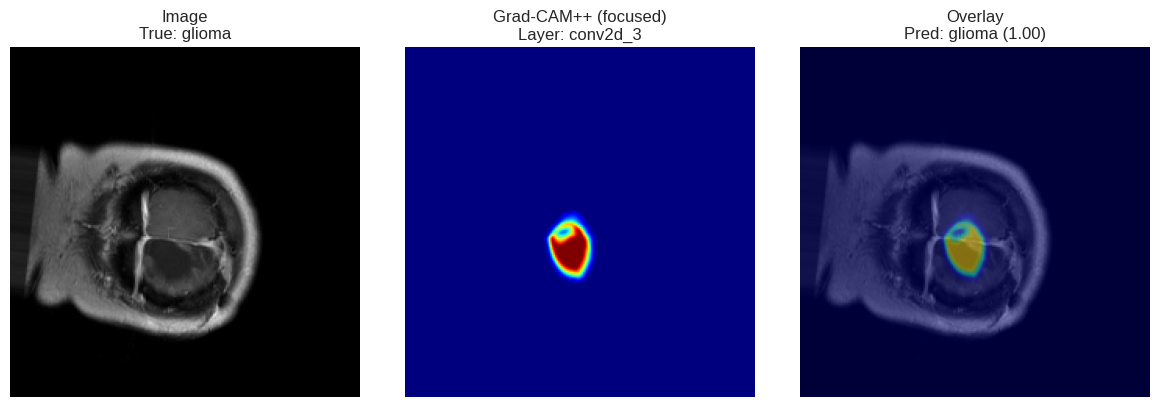

Saved to: /content/xai_outputs


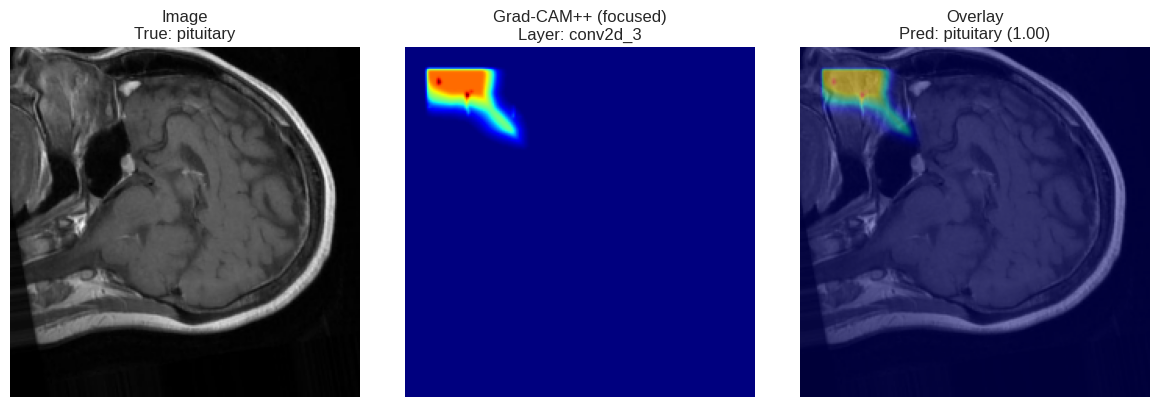

Saved to: /content/xai_outputs


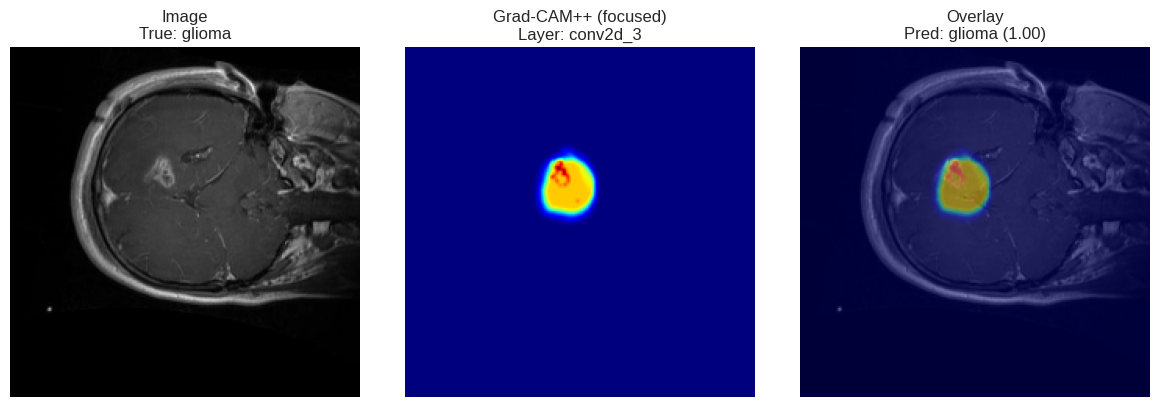

Saved to: /content/xai_outputs


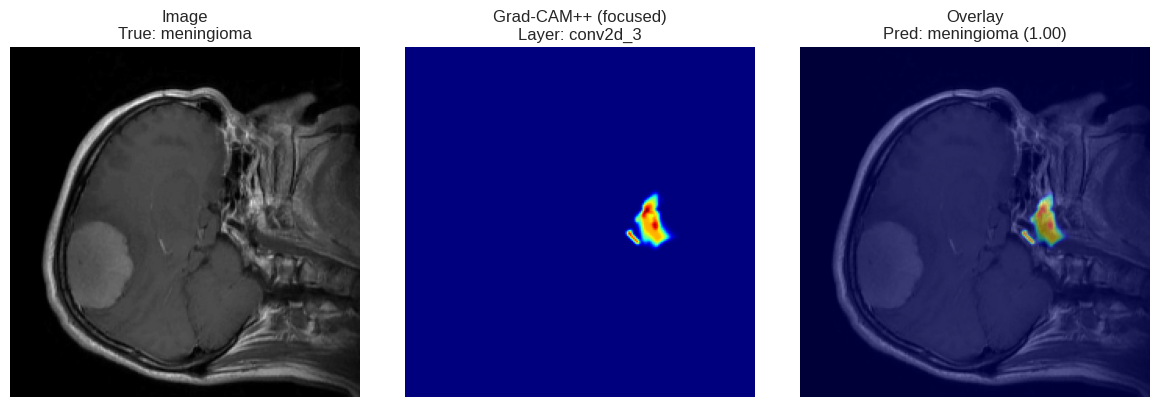

Saved to: /content/xai_outputs


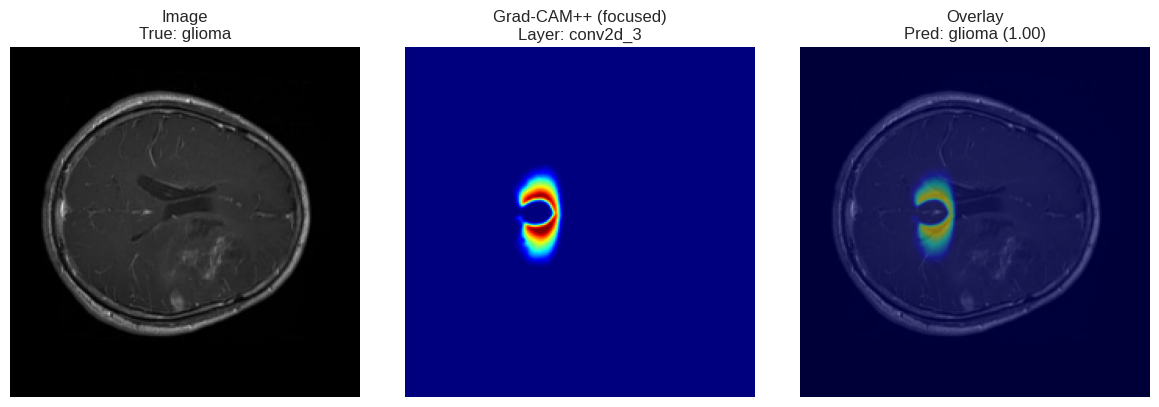

Saved to: /content/xai_outputs


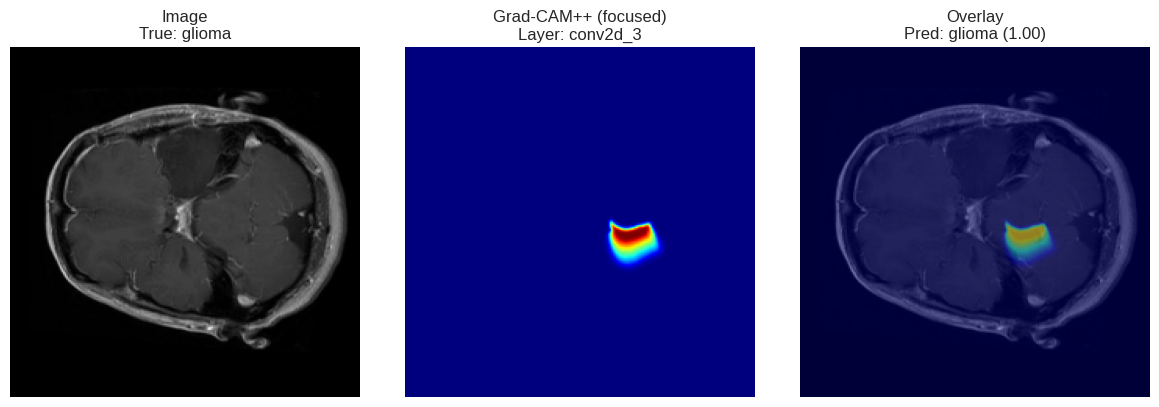

Saved to: /content/xai_outputs


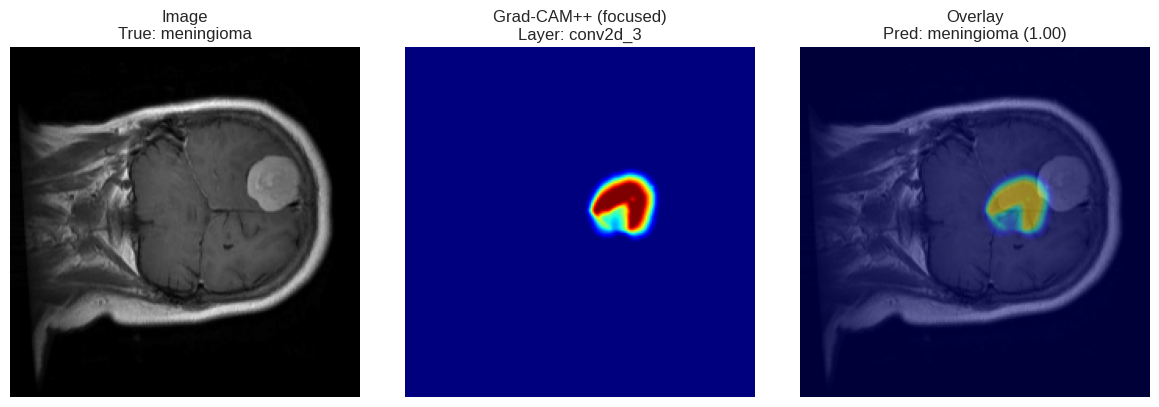

Saved to: /content/xai_outputs


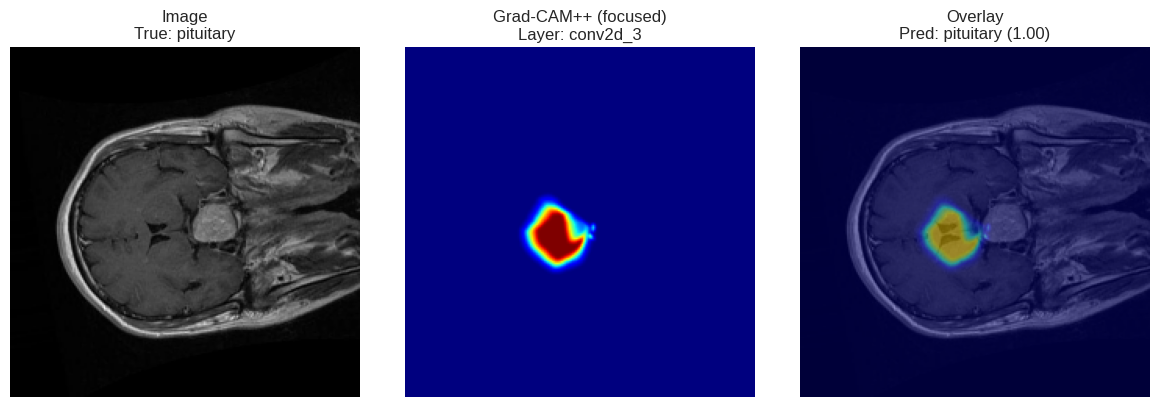

Saved to: /content/xai_outputs


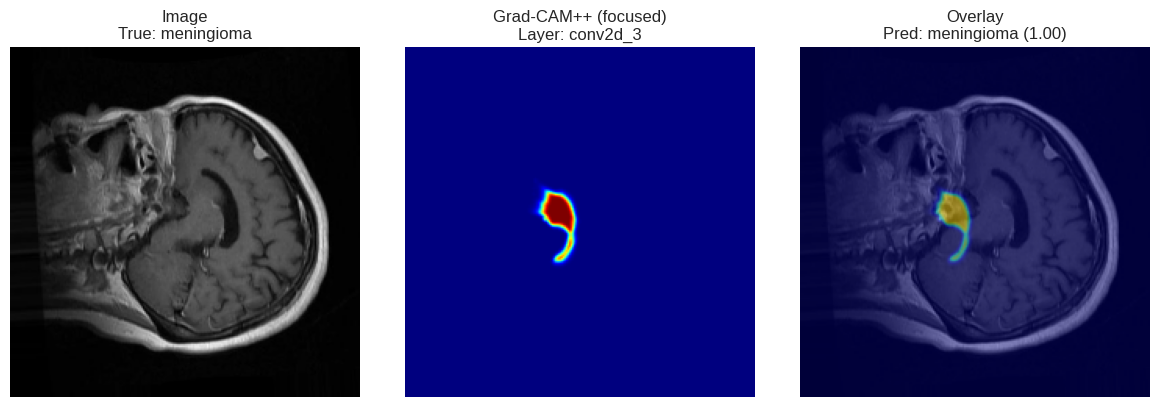

Saved to: /content/xai_outputs


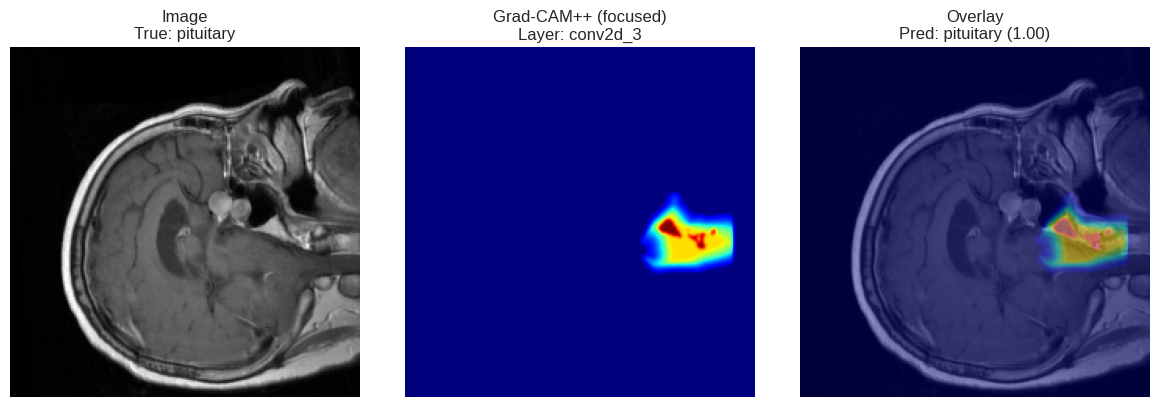

Saved to: /content/xai_outputs


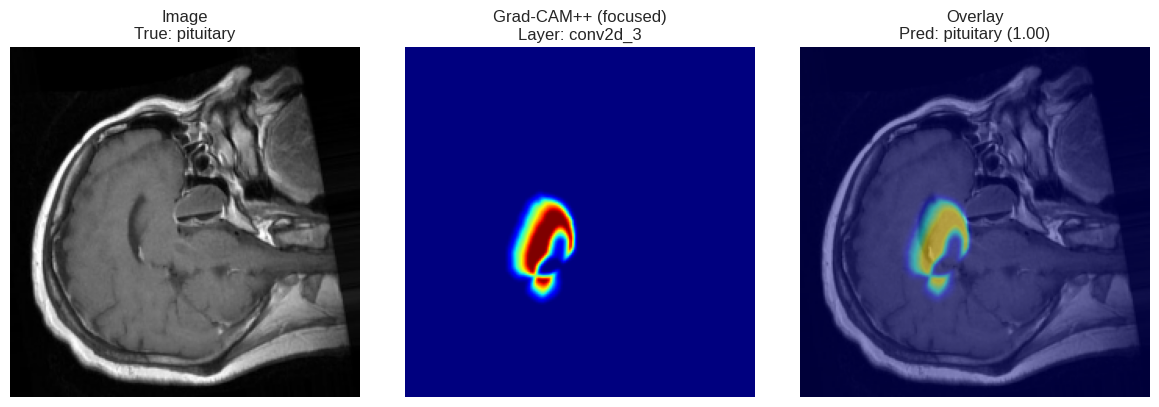

Saved to: /content/xai_outputs


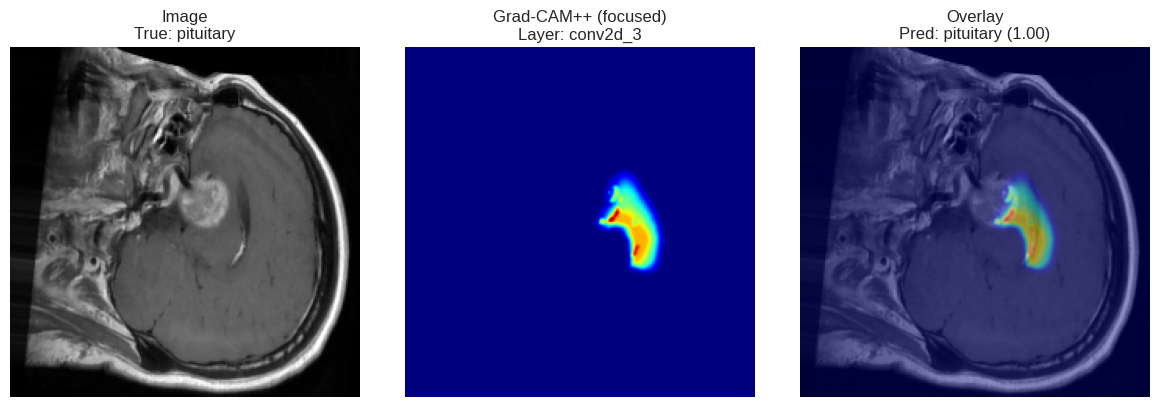

Saved to: /content/xai_outputs


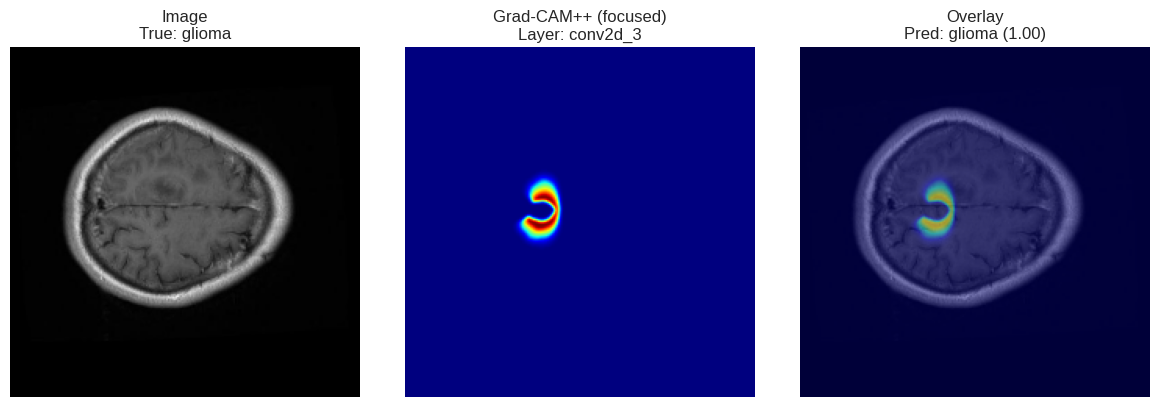

Saved to: /content/xai_outputs


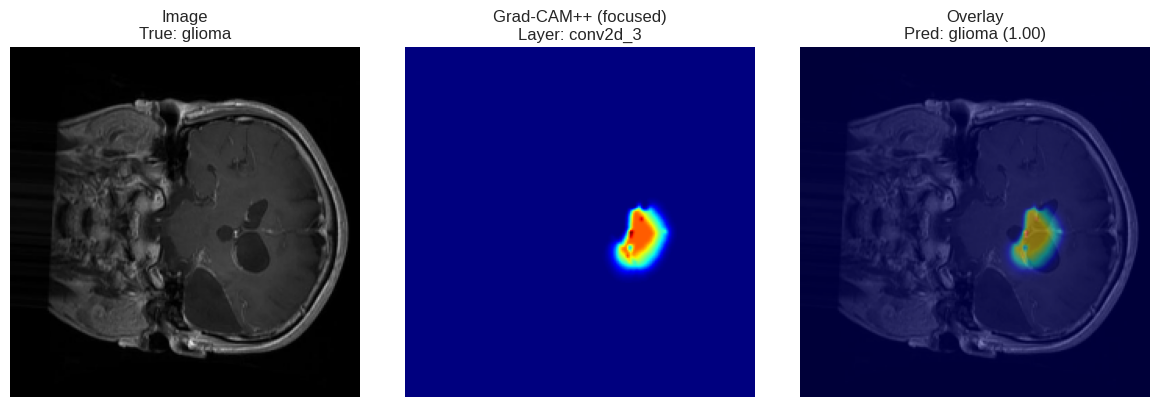

Saved to: /content/xai_outputs


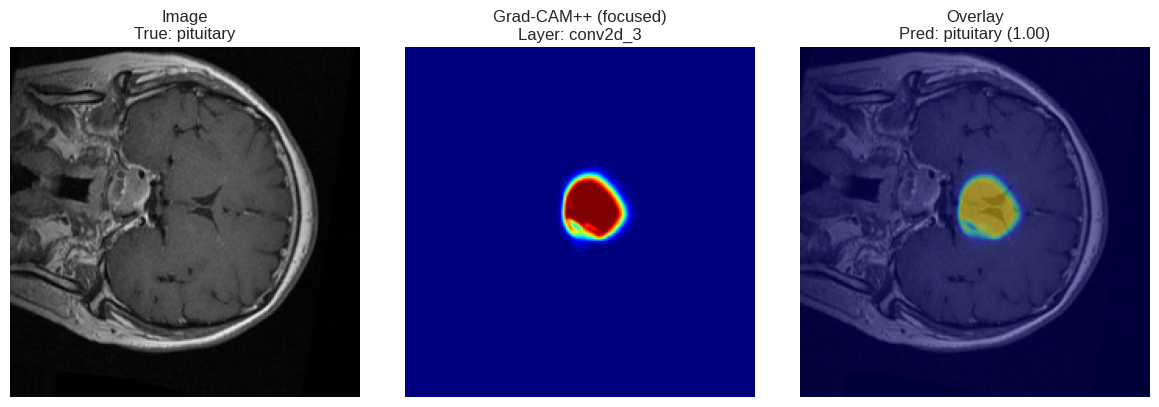

Saved to: /content/xai_outputs


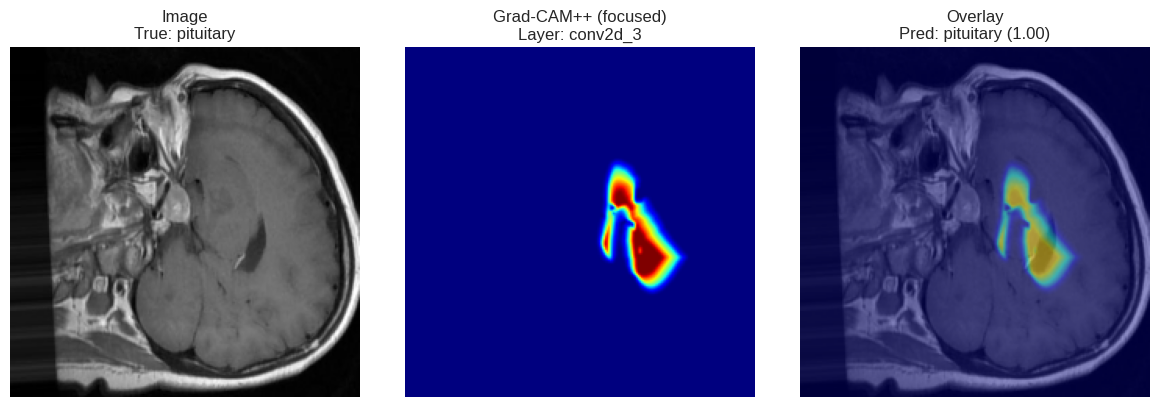

Saved to: /content/xai_outputs


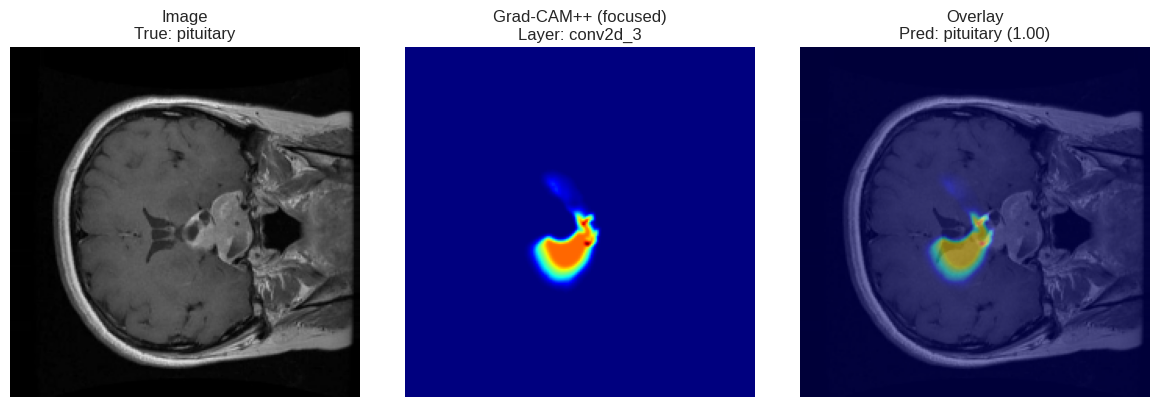

Saved to: /content/xai_outputs


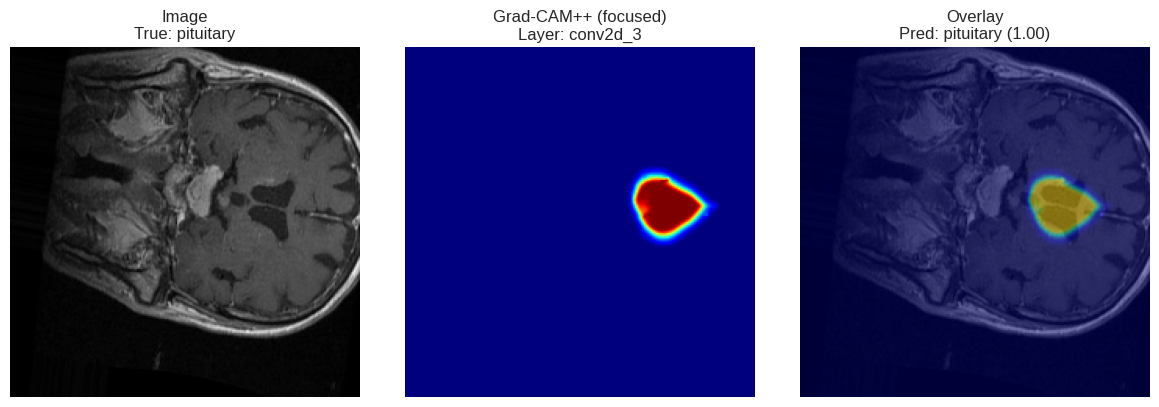

Saved to: /content/xai_outputs


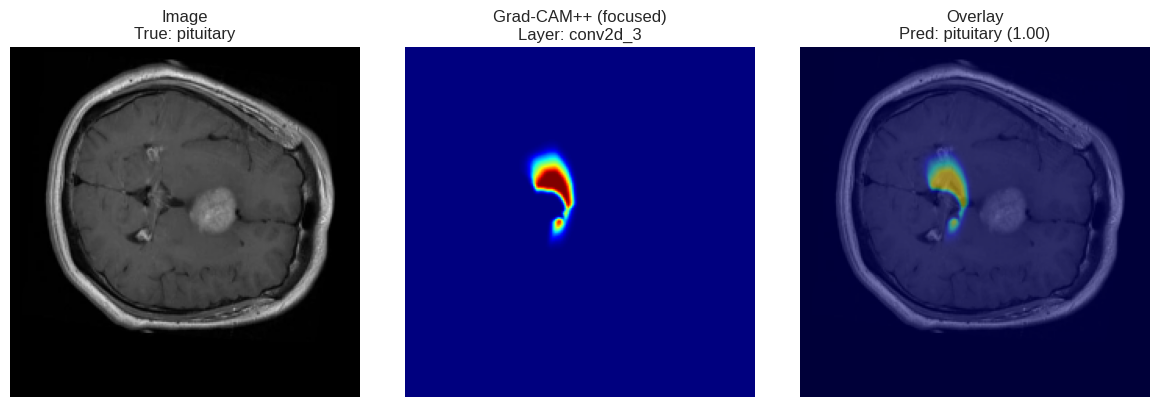

Saved to: /content/xai_outputs


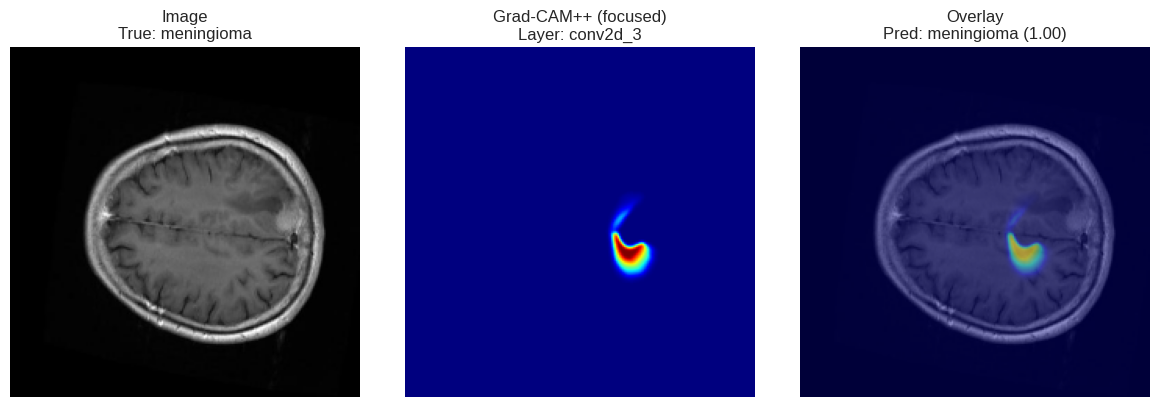

Saved to: /content/xai_outputs
Overlays dir: /content/xai_outputs
Saved log: /content/xai_outputs/xai_log.csv


In [45]:
# cell 45 - Save overlays for a batch and log a CSV (robust + fallback)

import os, pandas as pd, numpy as np, tempfile
from pathlib import Path

def pick_out_dir():
    # Try project root, then current dir, then home, else temp
    candidates = []
    proj = Path(r"D:\New folder (2)\BRAIN TUMAR")
    if proj.exists(): candidates.append(proj / "xai_outputs")
    candidates.append(Path.cwd() / "xai_outputs")
    candidates.append(Path.home() / "xai_outputs")
    for p in candidates:
        try:
            p.mkdir(parents=True, exist_ok=True)
            return p
        except Exception as e:
            print(f"Cannot create {p}: {e}")
    tmp = Path(tempfile.mkdtemp(prefix="xai_outputs_"))
    print("Fallback temp dir:", tmp)
    return tmp / "xai_outputs"

OUT = pick_out_dir()
print("Using output dir:", OUT)

def save_xai_with_log(start=0, end=24, conv=None):
    rows = []
    old_cwd = Path.cwd()

    # Ensure gradcampp_show (Cell 43) saves into OUT by setting cwd to OUT.parent
    if OUT.name.lower() == "xai_outputs":
        base_dir = OUT.parent
        overlays_dir = OUT
    else:
        base_dir = OUT
        overlays_dir = OUT / "xai_outputs"
    overlays_dir.mkdir(parents=True, exist_ok=True)

    try:
        os.chdir(base_dir)  # Cell 43 saves to os.getcwd()/xai_outputs
        for i in range(start, min(end, len(xtest))):
            try:
                hm, ov, probs = gradcampp_show(sample_idx=i, conv_name=conv, save=True)
                pred_id = int(np.argmax(probs))
                true_id = int(ytest[i])
                try:
                    pred_name = inv_classes[pred_id]
                    true_name = inv_classes[true_id]
                except Exception:
                    pred_name, true_name = str(pred_id), str(true_id)
                rows.append({
                    "index": i,
                    "true_id": true_id, "true_name": true_name,
                    "pred_id": pred_id, "pred_name": pred_name,
                    "pred_prob": float(probs[pred_id])
                })
            except Exception as e:
                print(f"Idx {i}: failed -> {e}")
    finally:
        os.chdir(old_cwd)

    df = pd.DataFrame(rows)
    csv_path = overlays_dir / "xai_log.csv"
    df.to_csv(csv_path, index=False)
    print("Overlays dir:", overlays_dir)
    print("Saved log:", csv_path)

# Example: first 24 test images
save_xai_with_log(0, 24)

## LIME & SHAP – Model-Agnostic Explainability

In addition to gradient-based methods (Grad-CAM, Grad-CAM++), we employ two
model-agnostic XAI techniques:

| Method | Full Name | Principle |
|--------|-----------|-----------|
| **LIME** | Local Interpretable Model-agnostic Explanations | Perturbs super-pixel regions and fits a local linear model to approximate the classifier's decision boundary around a single instance. |
| **SHAP** | SHapley Additive exPlanations | Uses Shapley values from cooperative game theory to assign each pixel/super-pixel a fair contribution score toward the prediction. |

These methods complement Grad-CAM by providing **architecture-independent** explanations.

In [46]:
# cell 46 - Install LIME & SHAP (run once)
!pip install lime shap --quiet
print("✅ lime and shap installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ lime and shap installed.



LIME Explanation for test sample 0


  0%|          | 0/1000 [00:00<?, ?it/s]

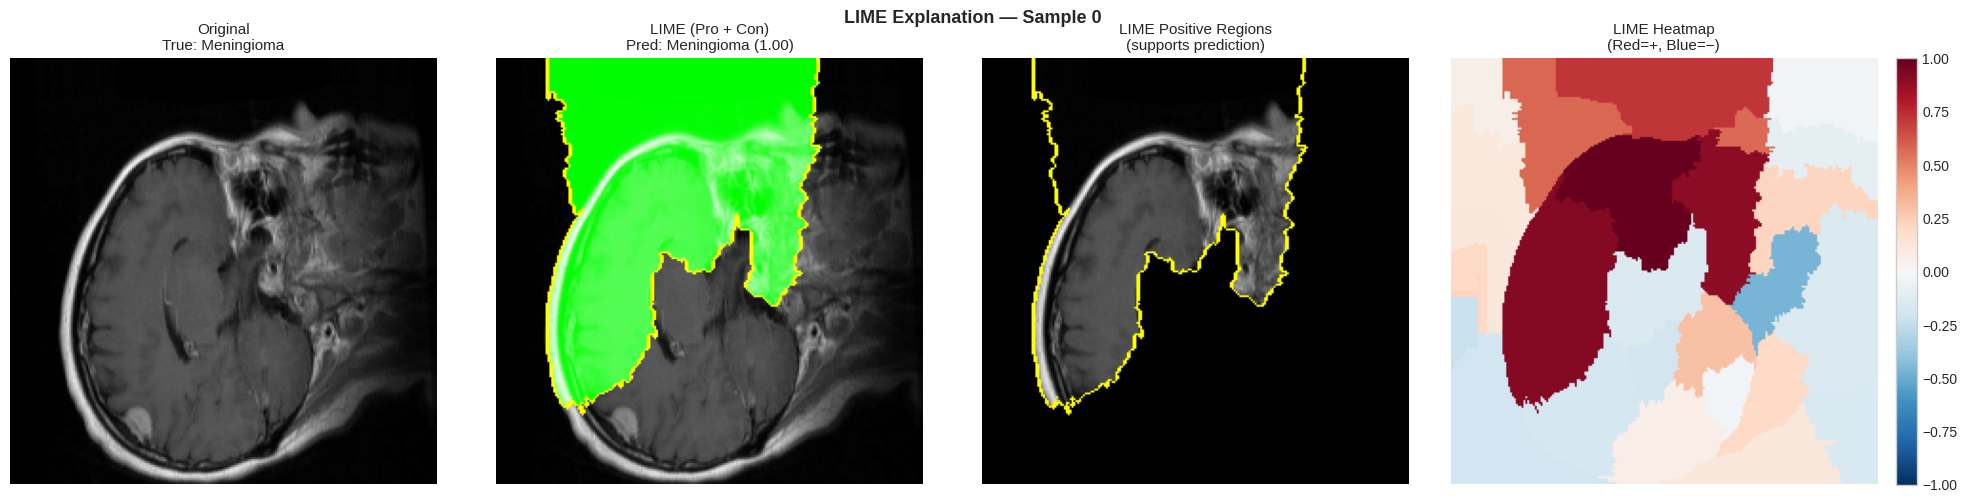


LIME Explanation for test sample 1


  0%|          | 0/1000 [00:00<?, ?it/s]

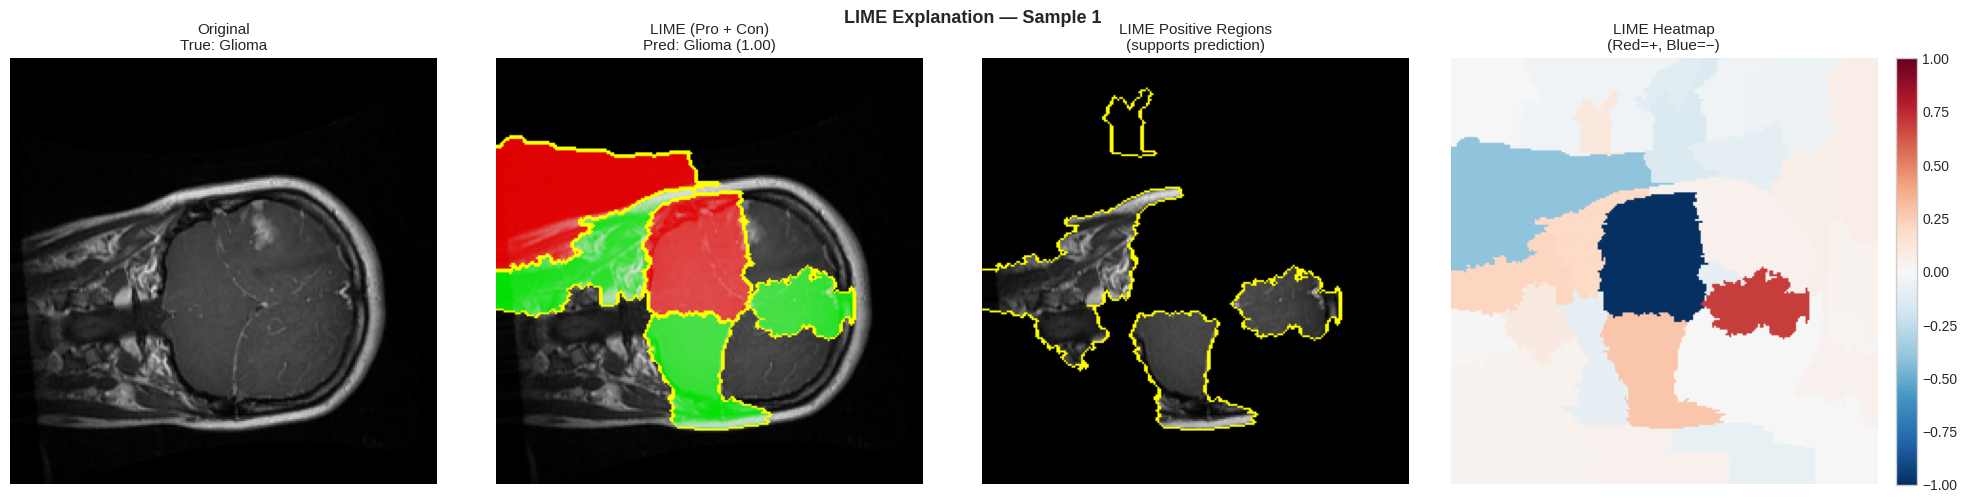


LIME Explanation for test sample 2


  0%|          | 0/1000 [00:00<?, ?it/s]

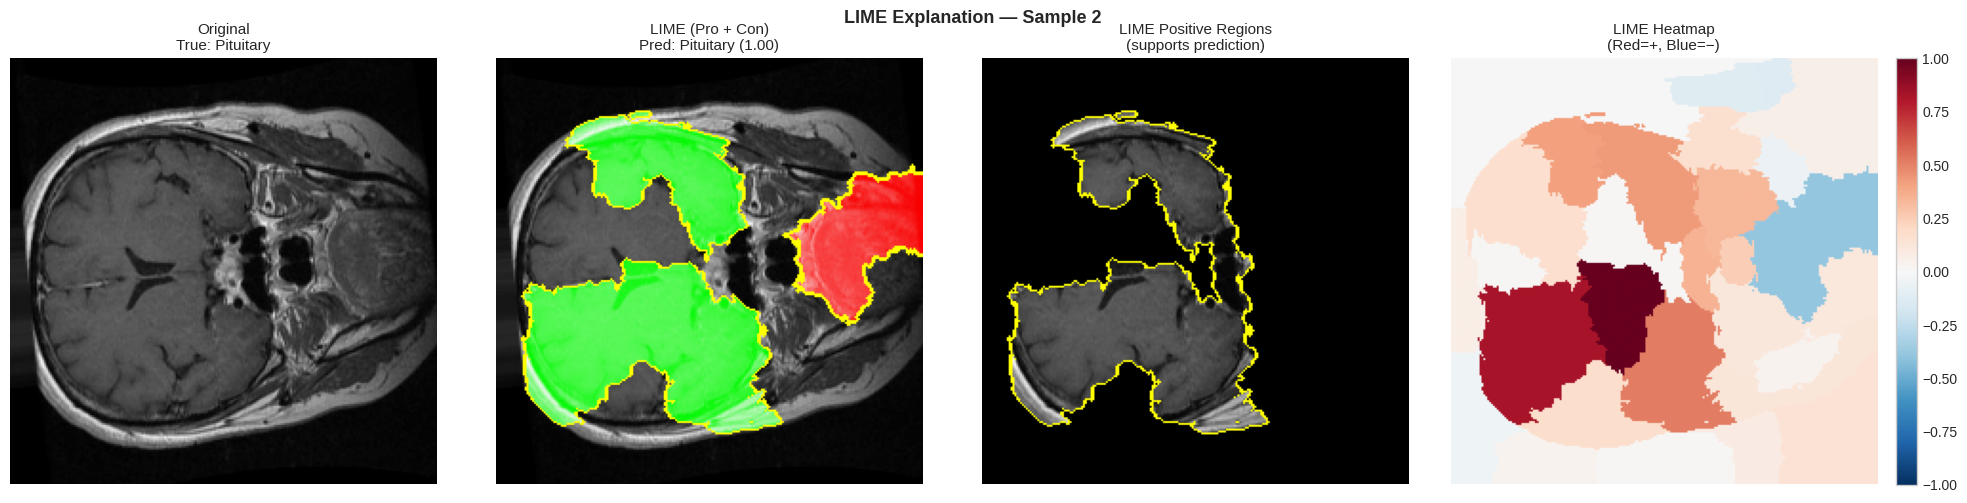

In [47]:
# cell 47 - LIME Explanation for Brain Tumor Classification

import numpy as np, cv2, matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries

# ──────────────────────────────────────────────────────────
# Prediction wrapper: LIME feeds RGB float64 images in [0,1].
# Our model expects BGR uint8 [0,255] (same as cv2.imread).
# ──────────────────────────────────────────────────────────
def lime_predict_fn(images_rgb_float):
    """
    images_rgb_float: (N, H, W, 3) float64 in [0, 1] range, RGB order.
    Returns: (N, num_classes) softmax probabilities.
    """
    batch = []
    for img in images_rgb_float:
        # Convert RGB [0,1] → BGR [0,255] to match training format
        img_uint8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGR)
        batch.append(img_bgr.astype(np.float32))
    batch = np.array(batch)
    preds = model.predict(batch, verbose=0)
    return preds

# ──────────────────────────────────────────────────────────
# Run LIME on selected test samples
# ──────────────────────────────────────────────────────────
class_names_list = ['Glioma', 'Meningioma', 'Pituitary']

def lime_explain(sample_idx=0, num_features=6, num_samples=1000,
                 positive_only=False):
    """Generate LIME explanation for a single test image."""
    img_bgr = xtest[sample_idx]

    # Convert BGR [0,255] → RGB [0,1] for LIME
    img_rgb = cv2.cvtColor(_to_uint8(img_bgr), cv2.COLOR_BGR2RGB)
    img_rgb_float = img_rgb.astype(np.float64) / 255.0

    # Create LIME explainer
    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img_rgb_float,
        lime_predict_fn,
        top_labels=3,
        hide_color=0,
        num_samples=num_samples,
        random_seed=42
    )

    # Get prediction
    probs = model.predict(np.expand_dims(img_bgr.astype(np.float32), 0), verbose=0)[0]
    pred_id = int(np.argmax(probs))
    true_id = int(ytest[sample_idx])
    pred_name = class_names_list[pred_id]
    true_name = class_names_list[true_id]

    # ── Visualization ──
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    # 1) Original image
    axes[0].imshow(img_rgb_float)
    axes[0].set_title(f"Original\nTrue: {true_name}", fontsize=11)
    axes[0].axis('off')

    # 2) LIME mask for predicted class (pros + cons)
    temp, mask = explanation.get_image_and_mask(
        pred_id, positive_only=False, num_features=num_features,
        hide_rest=False, min_weight=0.0
    )
    axes[1].imshow(mark_boundaries(temp, mask))
    axes[1].set_title(f"LIME (Pro + Con)\nPred: {pred_name} ({probs[pred_id]:.2f})", fontsize=11)
    axes[1].axis('off')

    # 3) LIME positive-only superpixels (regions supporting the prediction)
    temp_pos, mask_pos = explanation.get_image_and_mask(
        pred_id, positive_only=True, num_features=num_features,
        hide_rest=True, min_weight=0.0
    )
    axes[2].imshow(mark_boundaries(temp_pos, mask_pos))
    axes[2].set_title("LIME Positive Regions\n(supports prediction)", fontsize=11)
    axes[2].axis('off')

    # 4) LIME heatmap (weight per superpixel)
    dict_heatmap = dict(explanation.local_exp[pred_id])
    heatmap = np.zeros(explanation.segments.shape, dtype=np.float64)
    for seg_id, weight in dict_heatmap.items():
        heatmap[explanation.segments == seg_id] = weight
    abs_max = max(np.abs(heatmap).max(), 1e-8)
    heatmap_norm = heatmap / abs_max  # normalize to [-1, 1]

    im = axes[3].imshow(heatmap_norm, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[3].set_title("LIME Heatmap\n(Red=+, Blue=−)", fontsize=11)
    axes[3].axis('off')
    fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

    plt.suptitle(f"LIME Explanation — Sample {sample_idx}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return explanation

# ── Run on first 3 test samples ──
for idx in [0, 1, 2]:
    print(f"\n{'='*60}")
    print(f"LIME Explanation for test sample {idx}")
    print(f"{'='*60}")
    _ = lime_explain(sample_idx=idx, num_features=6, num_samples=1000)